In [1]:
!pip install torchview torchmetrics tqdm seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.9 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics
from torchview import draw_graph
from statsmodels.tsa.stattools import adfuller
import statsmodels.tsa.api as sm_ts_api
import statsmodels.api as sm_api
from tqdm import tqdm

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device=}")

device='cpu'


# EDA анализ

In [3]:
dataset = pd.read_csv("../data/datasets/train_val_1995-2018.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' +
    dataset['Decimal Day'].astype(str) +
    ' ' +
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
dataset = dataset[cols]
dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [4]:
dataset.columns

Index(['datetime', 'Bz_GSM', 'By_GSM', 'Bx_GSE', 'Kp', 'f10.7', 'AL', 'AU',
       'T_proton', 'Np_density', 'V_plasma', 'V_Long_GSE', 'V_Lat_GSE', 'Dst',
       'AE'],
      dtype='str')

In [9]:
fill_values = {
    "Bz_GSM": 999.9,
    "By_GSM": 999.9,
    "Bx_GSE": 999.9,
    "Kp": 99,
    "f10.7": 999.9,
    "AL": 99999,
    "AU": 99999,
    "T_proton": 9999999.,
    "Np_density": 999.9,
    "V_plasma": 9999.,
    "V_Long_GSE": 999.9,
    "V_Lat_GSE": 999.9,
    "Dst": 99999,
    "AE": 9999,
}
for col in dataset.drop(columns=["datetime"]).columns:
    dataset[col] = dataset[col].replace(fill_values[col], np.nan)

## Анализ пропусков

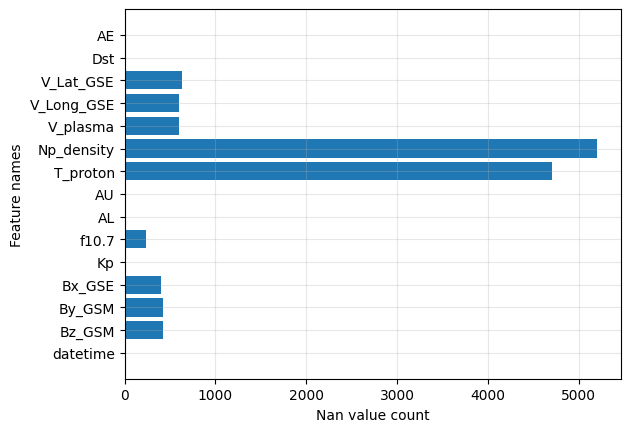

In [10]:
nan_counter = dataset.isna().sum()
plt.barh(nan_counter.index, nan_counter.values)
plt.xlabel("Nan value count")
plt.ylabel("Feature names")
plt.grid(alpha=0.3)
plt.show()

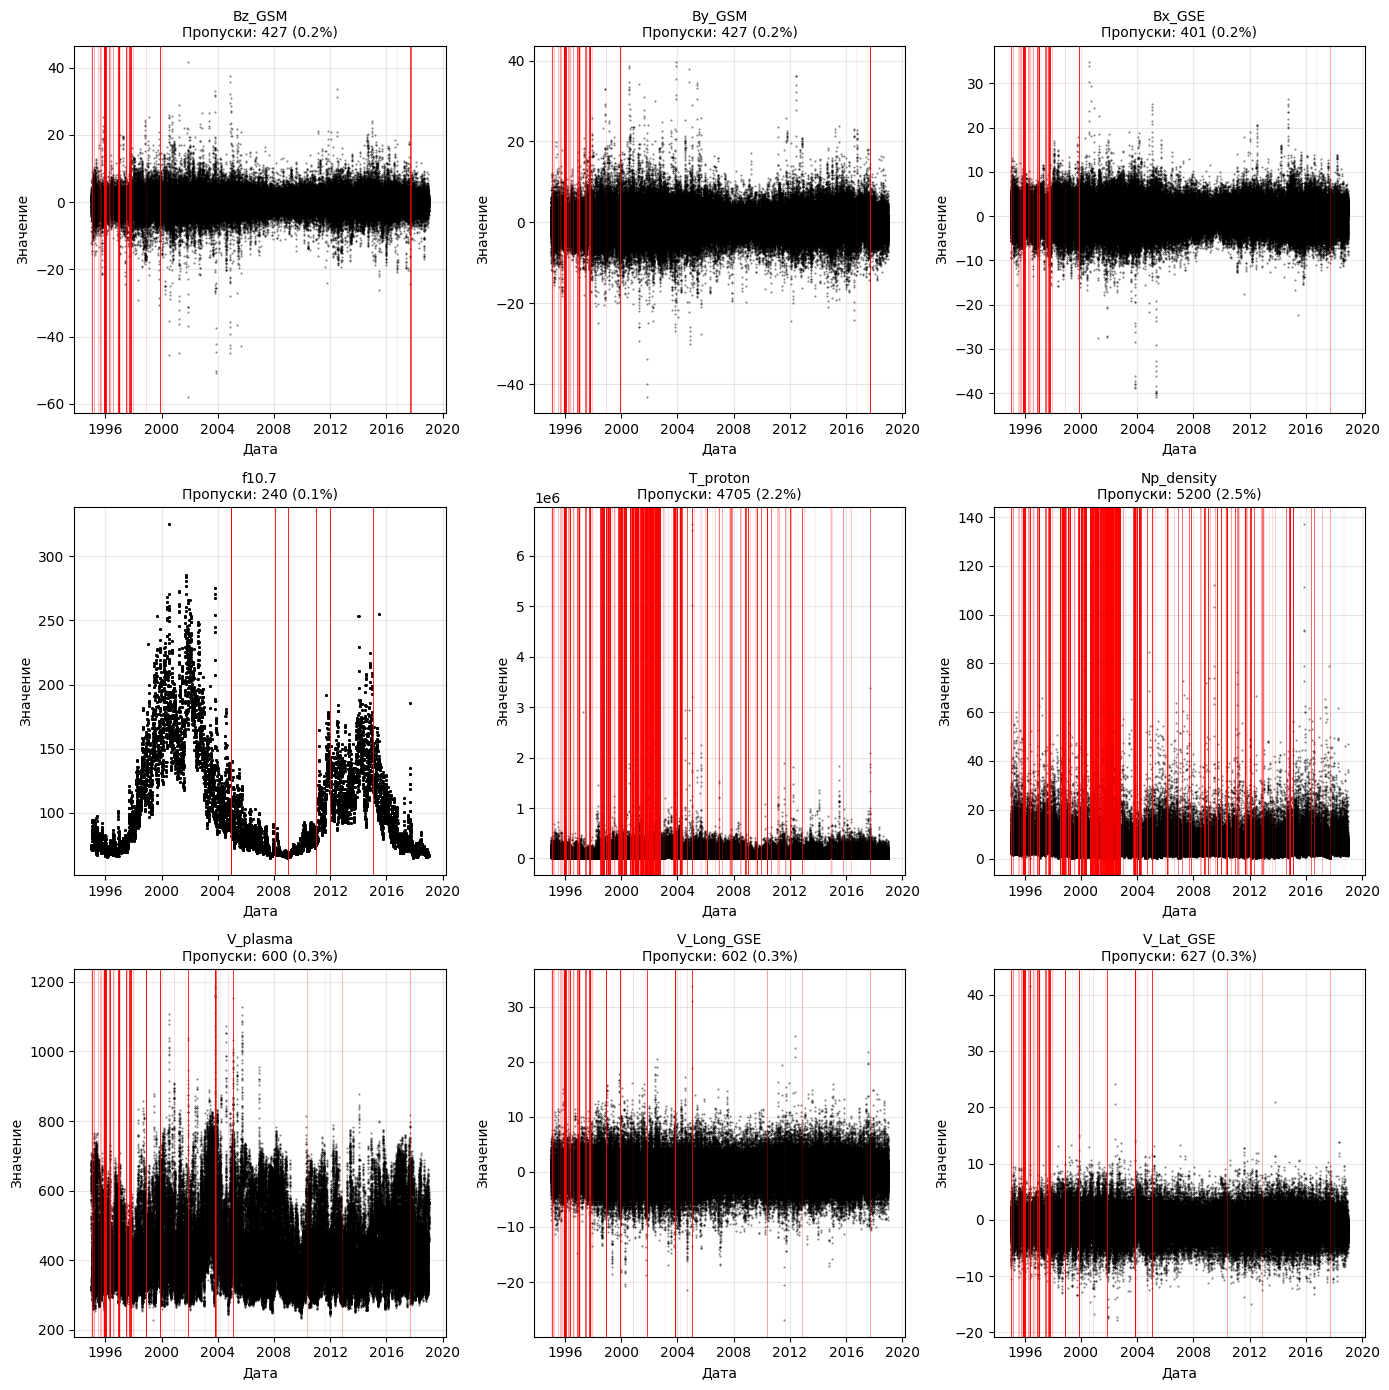

In [11]:
_, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

nan_cols = []
for k, v in nan_counter.items():
    if v != 0:
        nan_cols.append(k)

for idx, col in enumerate(nan_cols):
    ax = axes[idx]
    mask = ~dataset[col].isna()
    ax.plot(dataset.loc[mask, 'datetime'], dataset.loc[mask, col], 'k.', markersize=1, alpha=0.5, label='Данные')
    nan_indices = dataset[dataset[col].isna()].index
    for nan_idx in nan_indices:
        ax.axvline(x=dataset.loc[nan_idx, 'datetime'], color='r', alpha=0.1, linewidth=0.5)
    ax.set_title(f'{col}\nПропуски: {dataset[col].isna().sum()} ({dataset[col].isna().sum()/len(dataset)*100:.1f}%)', fontsize=10)
    ax.set_xlabel('Дата')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

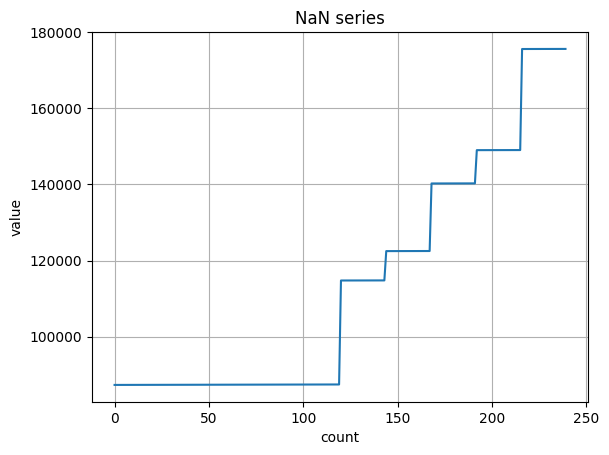

In [12]:
nan_indices_list = dataset[dataset["f10.7"].isna()].index.tolist()
plt.plot(nan_indices_list)
plt.title("NaN series")
plt.xlabel("count")
plt.ylabel("value")
plt.grid()
plt.show()

In [13]:
def find_nan_series(df: pd.DataFrame, feature: str, nan_seq_treshold: int = 1):
    nan_indices_list = df[df[feature].isna()].index.tolist()
    result = []
    start = nan_indices_list[0]
    end = nan_indices_list[0]
    for i in range(1, len(nan_indices_list)):
        if nan_indices_list[i] - nan_indices_list[i-1] <= nan_seq_treshold:
            end = nan_indices_list[i]
        else:
            result.append({"start": start, "end": end})
            start = nan_indices_list[i]
            end = nan_indices_list[i]
    result.append({"start": start, "end": end})

    return result, nan_indices_list


find_nan_series(dataset, "f10.7");

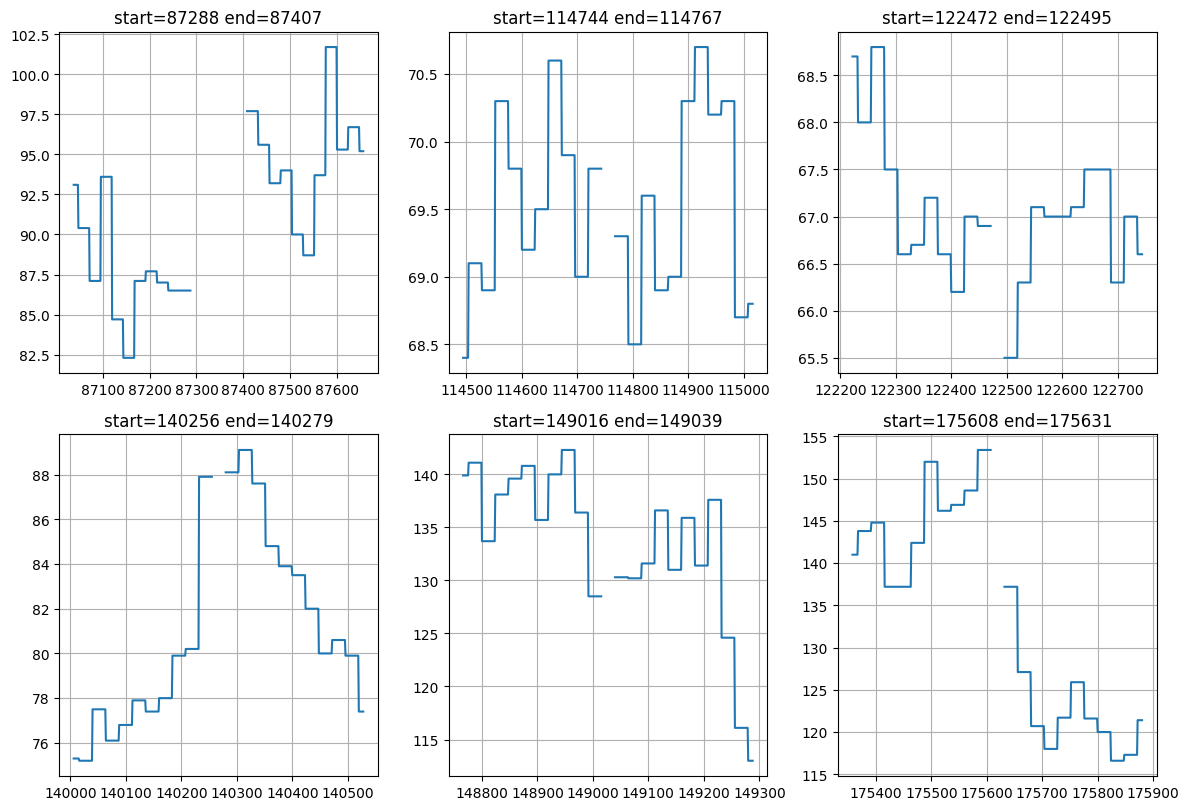

In [14]:
def visualize_nans(df, feature, history_additional, figsize):
    nans, nan_indices_list = find_nan_series(df, feature)
    grid_size = int(np.sqrt(len(nans))) + 1
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten()

    for idx, s in enumerate(nans):
        start, end = s["start"], s["end"]
        axes[idx].plot(df[feature].iloc[start-history_additional:end+history_additional])
        axes[idx].set_title(f"{start=} {end=}")
        axes[idx].grid()

    for i in range(idx+1, grid_size**2):
        fig.delaxes(axes[i])
    plt.tight_layout()
    plt.show()
    return nans, nan_indices_list


history_additional = 250
f107_nans, _ = visualize_nans(
    dataset,
    "f10.7",
    history_additional,
    figsize=(12, 12)
);

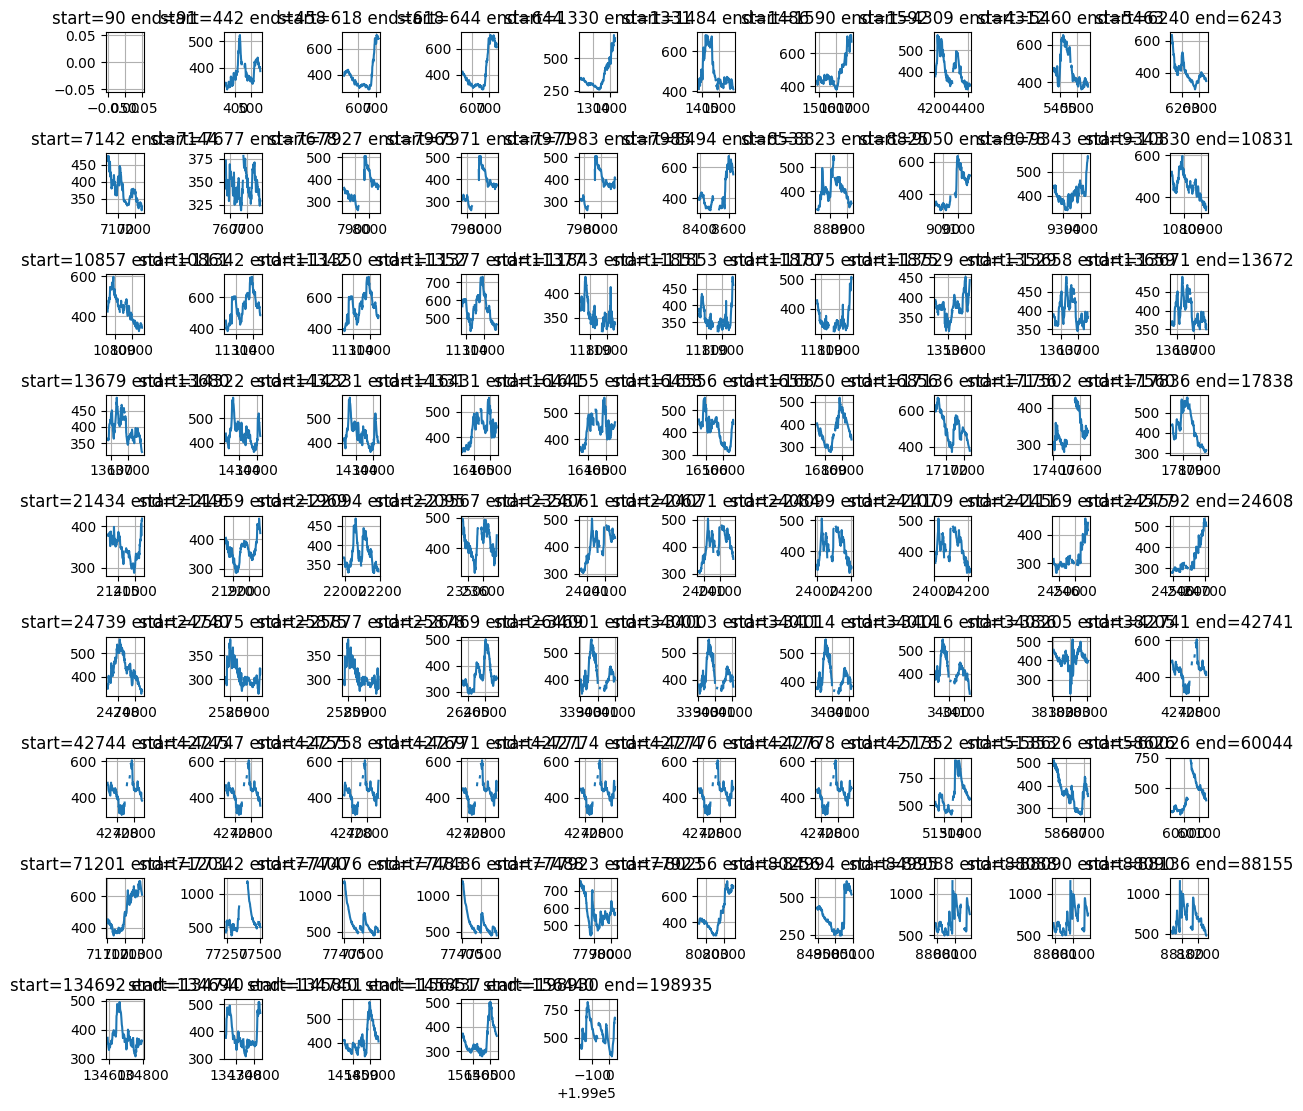

In [15]:
history_additional = 100
_, nan_indices_list = visualize_nans(
    dataset,
    "V_plasma",
    history_additional,
    figsize=(12, 12)
)

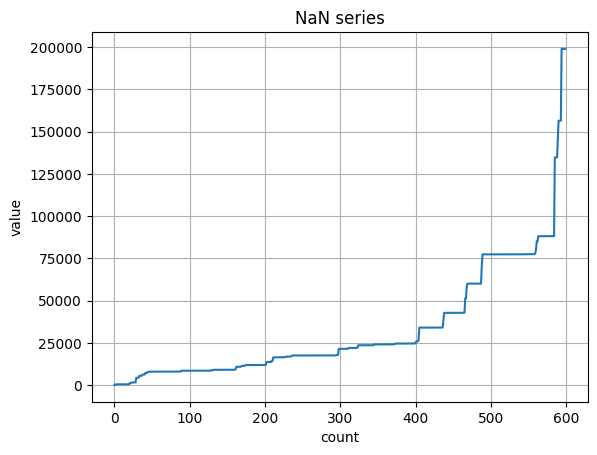

In [16]:
plt.plot(nan_indices_list)
plt.title("NaN series")
plt.xlabel("count")
plt.ylabel("value")
plt.grid()
plt.show()

/tmp/ipykernel_2074/2655722905.py:15: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


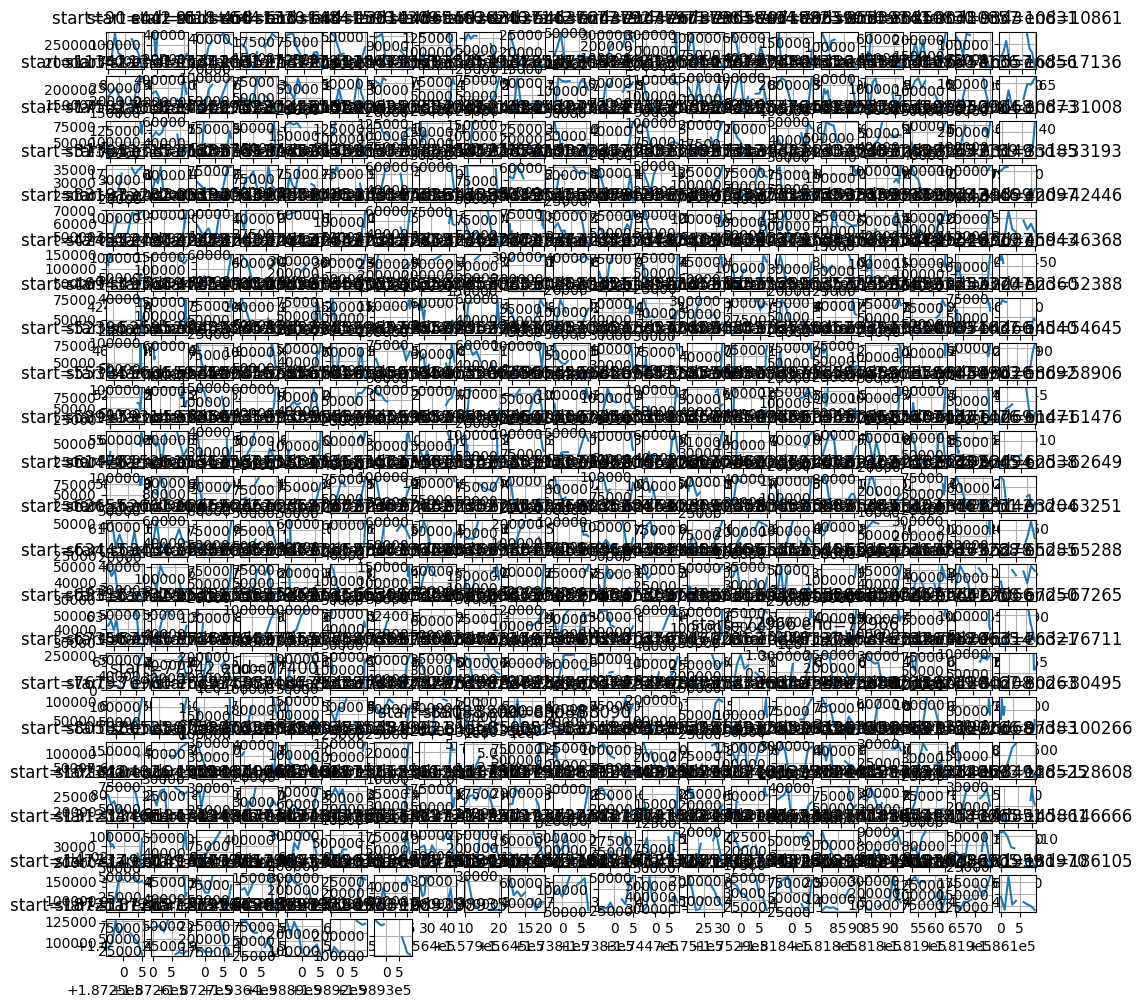

In [17]:
history_additional = 5
nans, nan_indices_list = visualize_nans(
    dataset,
    "T_proton",
    history_additional,
    figsize=(12, 12)
)

In [18]:
nans[:20]

[{'start': 90, 'end': 91},
 {'start': 442, 'end': 458},
 {'start': 618, 'end': 618},
 {'start': 644, 'end': 644},
 {'start': 1330, 'end': 1331},
 {'start': 1484, 'end': 1486},
 {'start': 1590, 'end': 1592},
 {'start': 4309, 'end': 4312},
 {'start': 5460, 'end': 5463},
 {'start': 6240, 'end': 6243},
 {'start': 7142, 'end': 7144},
 {'start': 7677, 'end': 7678},
 {'start': 7927, 'end': 7965},
 {'start': 7971, 'end': 7971},
 {'start': 7983, 'end': 7985},
 {'start': 8494, 'end': 8533},
 {'start': 8823, 'end': 8825},
 {'start': 9050, 'end': 9078},
 {'start': 9343, 'end': 9343},
 {'start': 10830, 'end': 10831}]

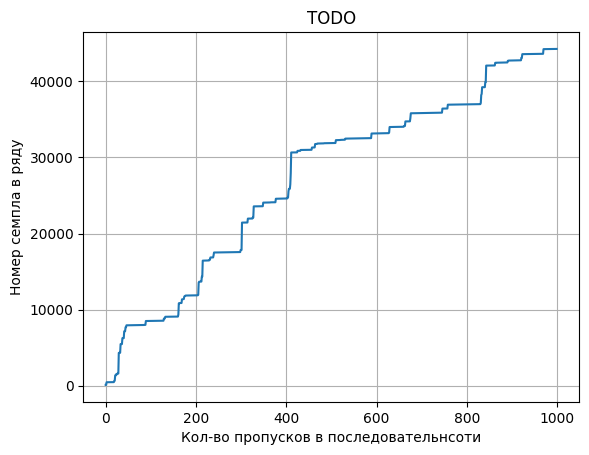

In [19]:
plt.plot(nan_indices_list[:1000])
plt.title("TODO")
plt.xlabel("Кол-во пропусков в последовательнсоти")
plt.ylabel("Номер семпла в ряду")
plt.grid()
plt.show()

In [20]:
f107_nans

[{'start': 87288, 'end': 87407},
 {'start': 114744, 'end': 114767},
 {'start': 122472, 'end': 122495},
 {'start': 140256, 'end': 140279},
 {'start': 149016, 'end': 149039},
 {'start': 175608, 'end': 175631}]

## Интерполирование пропусков в временных рядах

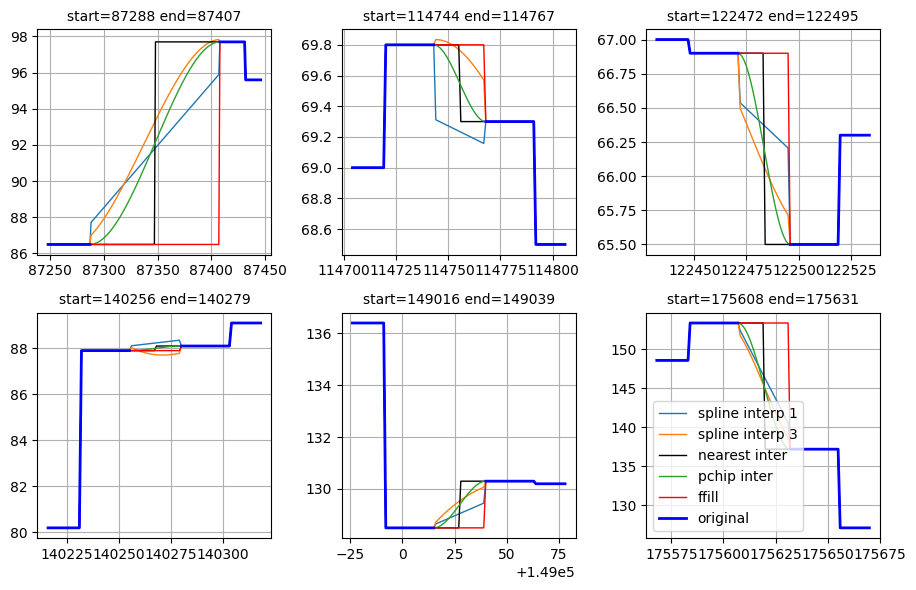

In [21]:
ffill_ds_copy = dataset.copy().ffill()
interpolated_df_copy = dataset.copy()
history_additional = 40
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

for s_idx, s in enumerate(f107_nans):
    start, end = s["start"], s["end"]
    from_, to = start-history_additional, end+history_additional
    axes[s_idx].plot(interpolated_df_copy["f10.7"].iloc[from_:to].interpolate(method='spline', order=1), linewidth=1, label="spline interp 1")
    axes[s_idx].plot(interpolated_df_copy["f10.7"].iloc[from_:to].interpolate(method='spline', order=3), linewidth=1, label="spline interp 3")
    axes[s_idx].plot(interpolated_df_copy["f10.7"].iloc[from_:to].interpolate(method='nearest'), linewidth=1, label="nearest inter", c="black")
    axes[s_idx].plot(interpolated_df_copy["f10.7"].iloc[from_:to].interpolate(method='pchip'), linewidth=1, label="pchip inter")
    axes[s_idx].plot(ffill_ds_copy["f10.7"].iloc[from_:to], c="red", label="ffill", linewidth=1)
    axes[s_idx].plot(dataset["f10.7"].iloc[from_:to], c="blue", label="original", linewidth=2)
    axes[s_idx].set_title(f"{start=} {end=}", fontsize=10)
    axes[s_idx].grid()
plt.tight_layout()
plt.legend()
plt.show()

In [22]:
dataset["f10.7"] = dataset["f10.7"].interpolate(method='pchip')

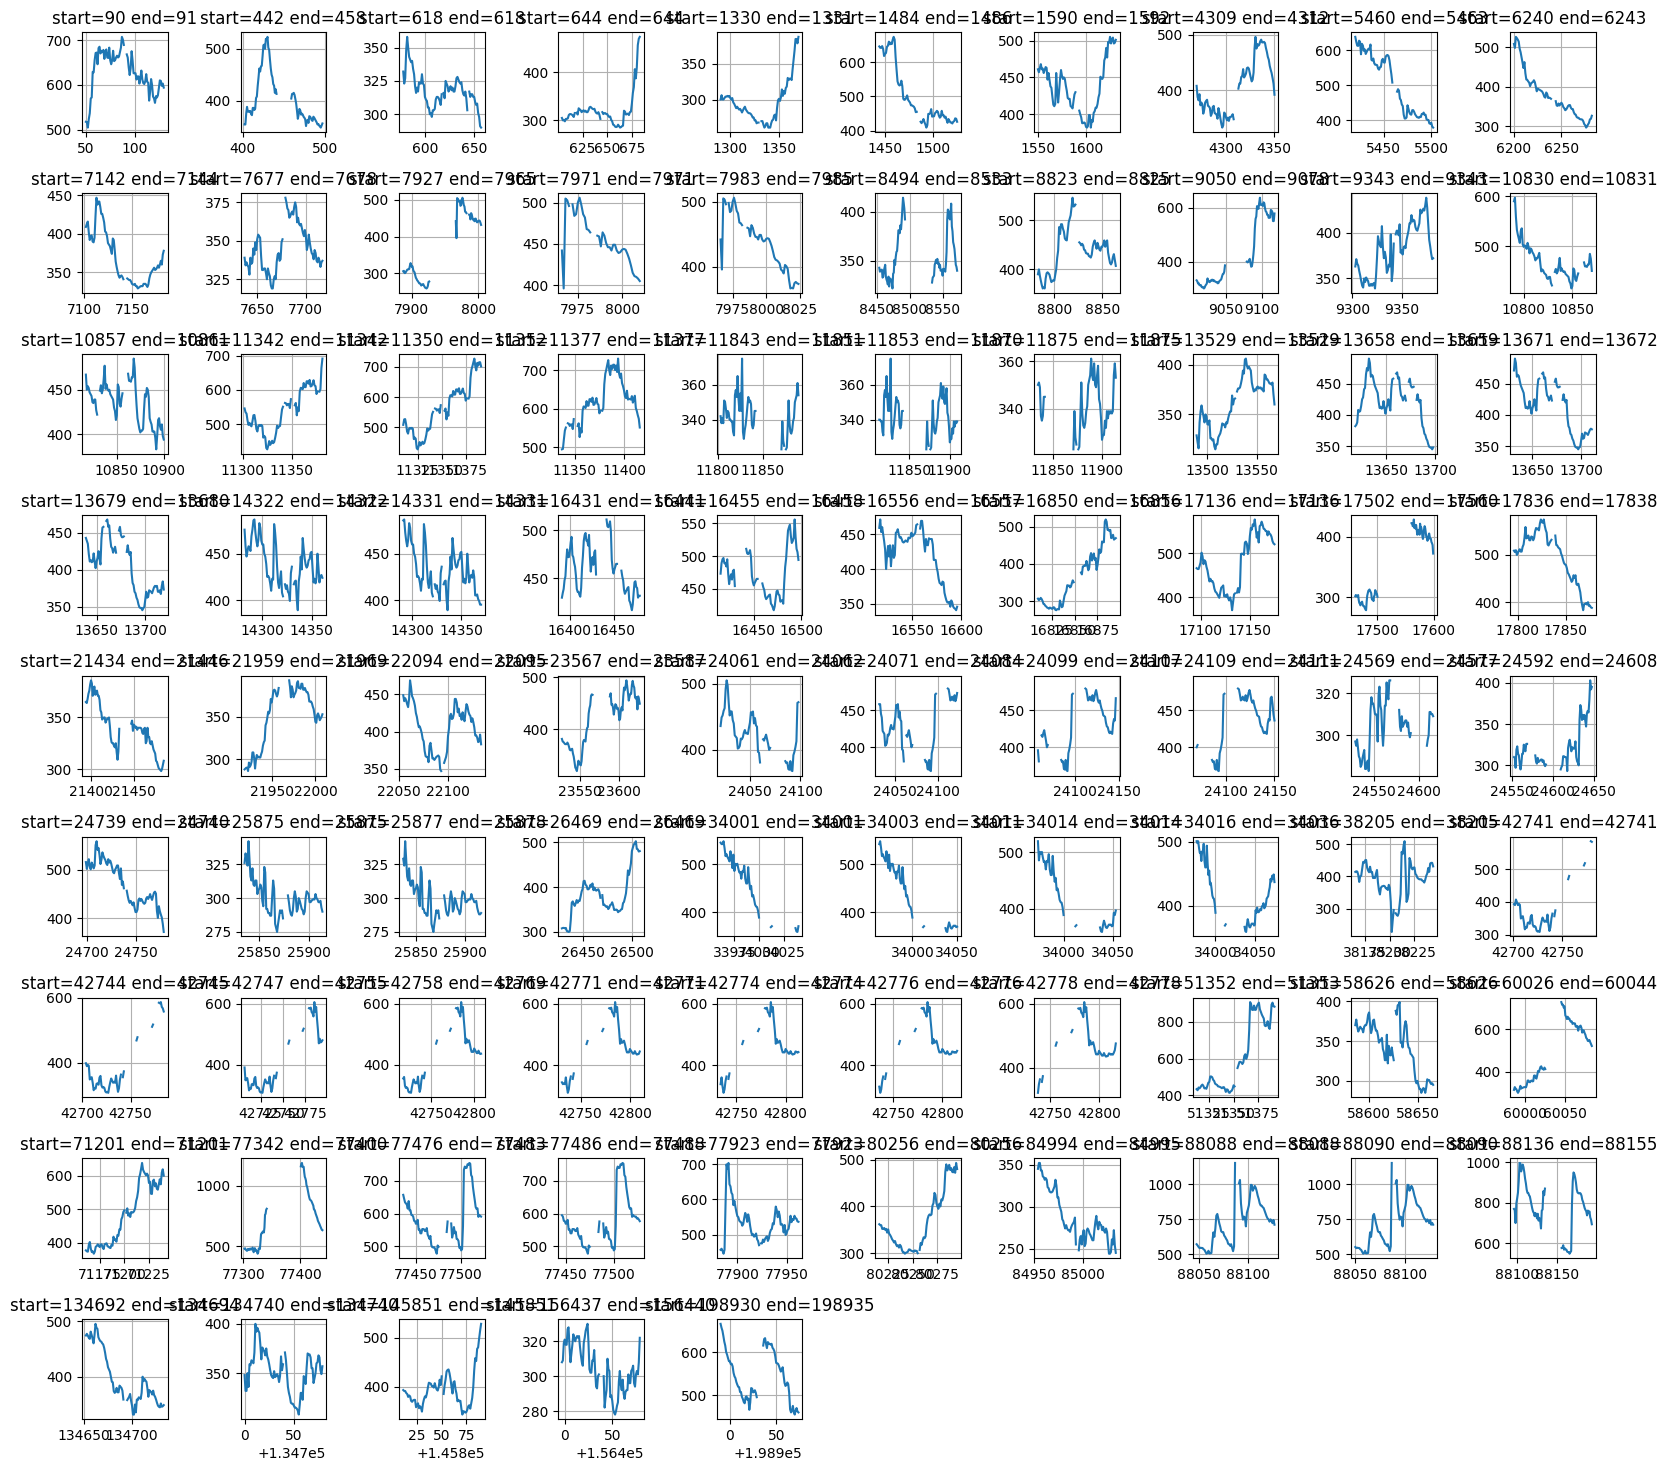

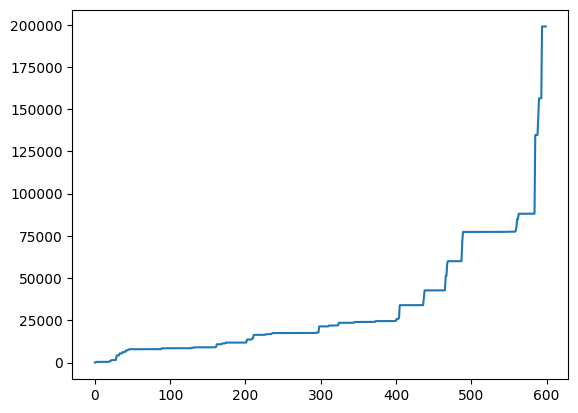

In [23]:
v_plasma_nans, v_plasma_nan_indices_list = visualize_nans(
    dataset,
    "V_plasma",
    history_additional,
    figsize=(16, 16)
);
plt.plot(v_plasma_nan_indices_list)

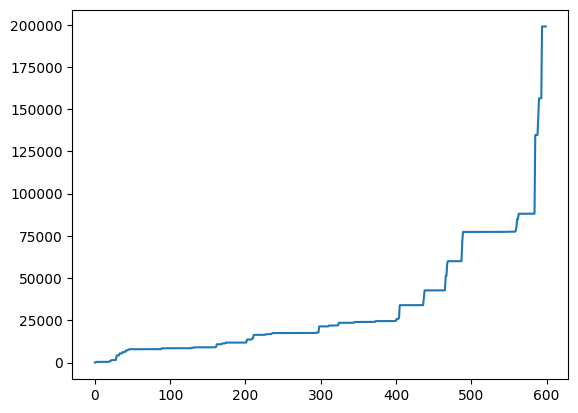

In [24]:
plt.plot(v_plasma_nan_indices_list)

/tmp/ipykernel_2074/2477966711.py:33: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend(


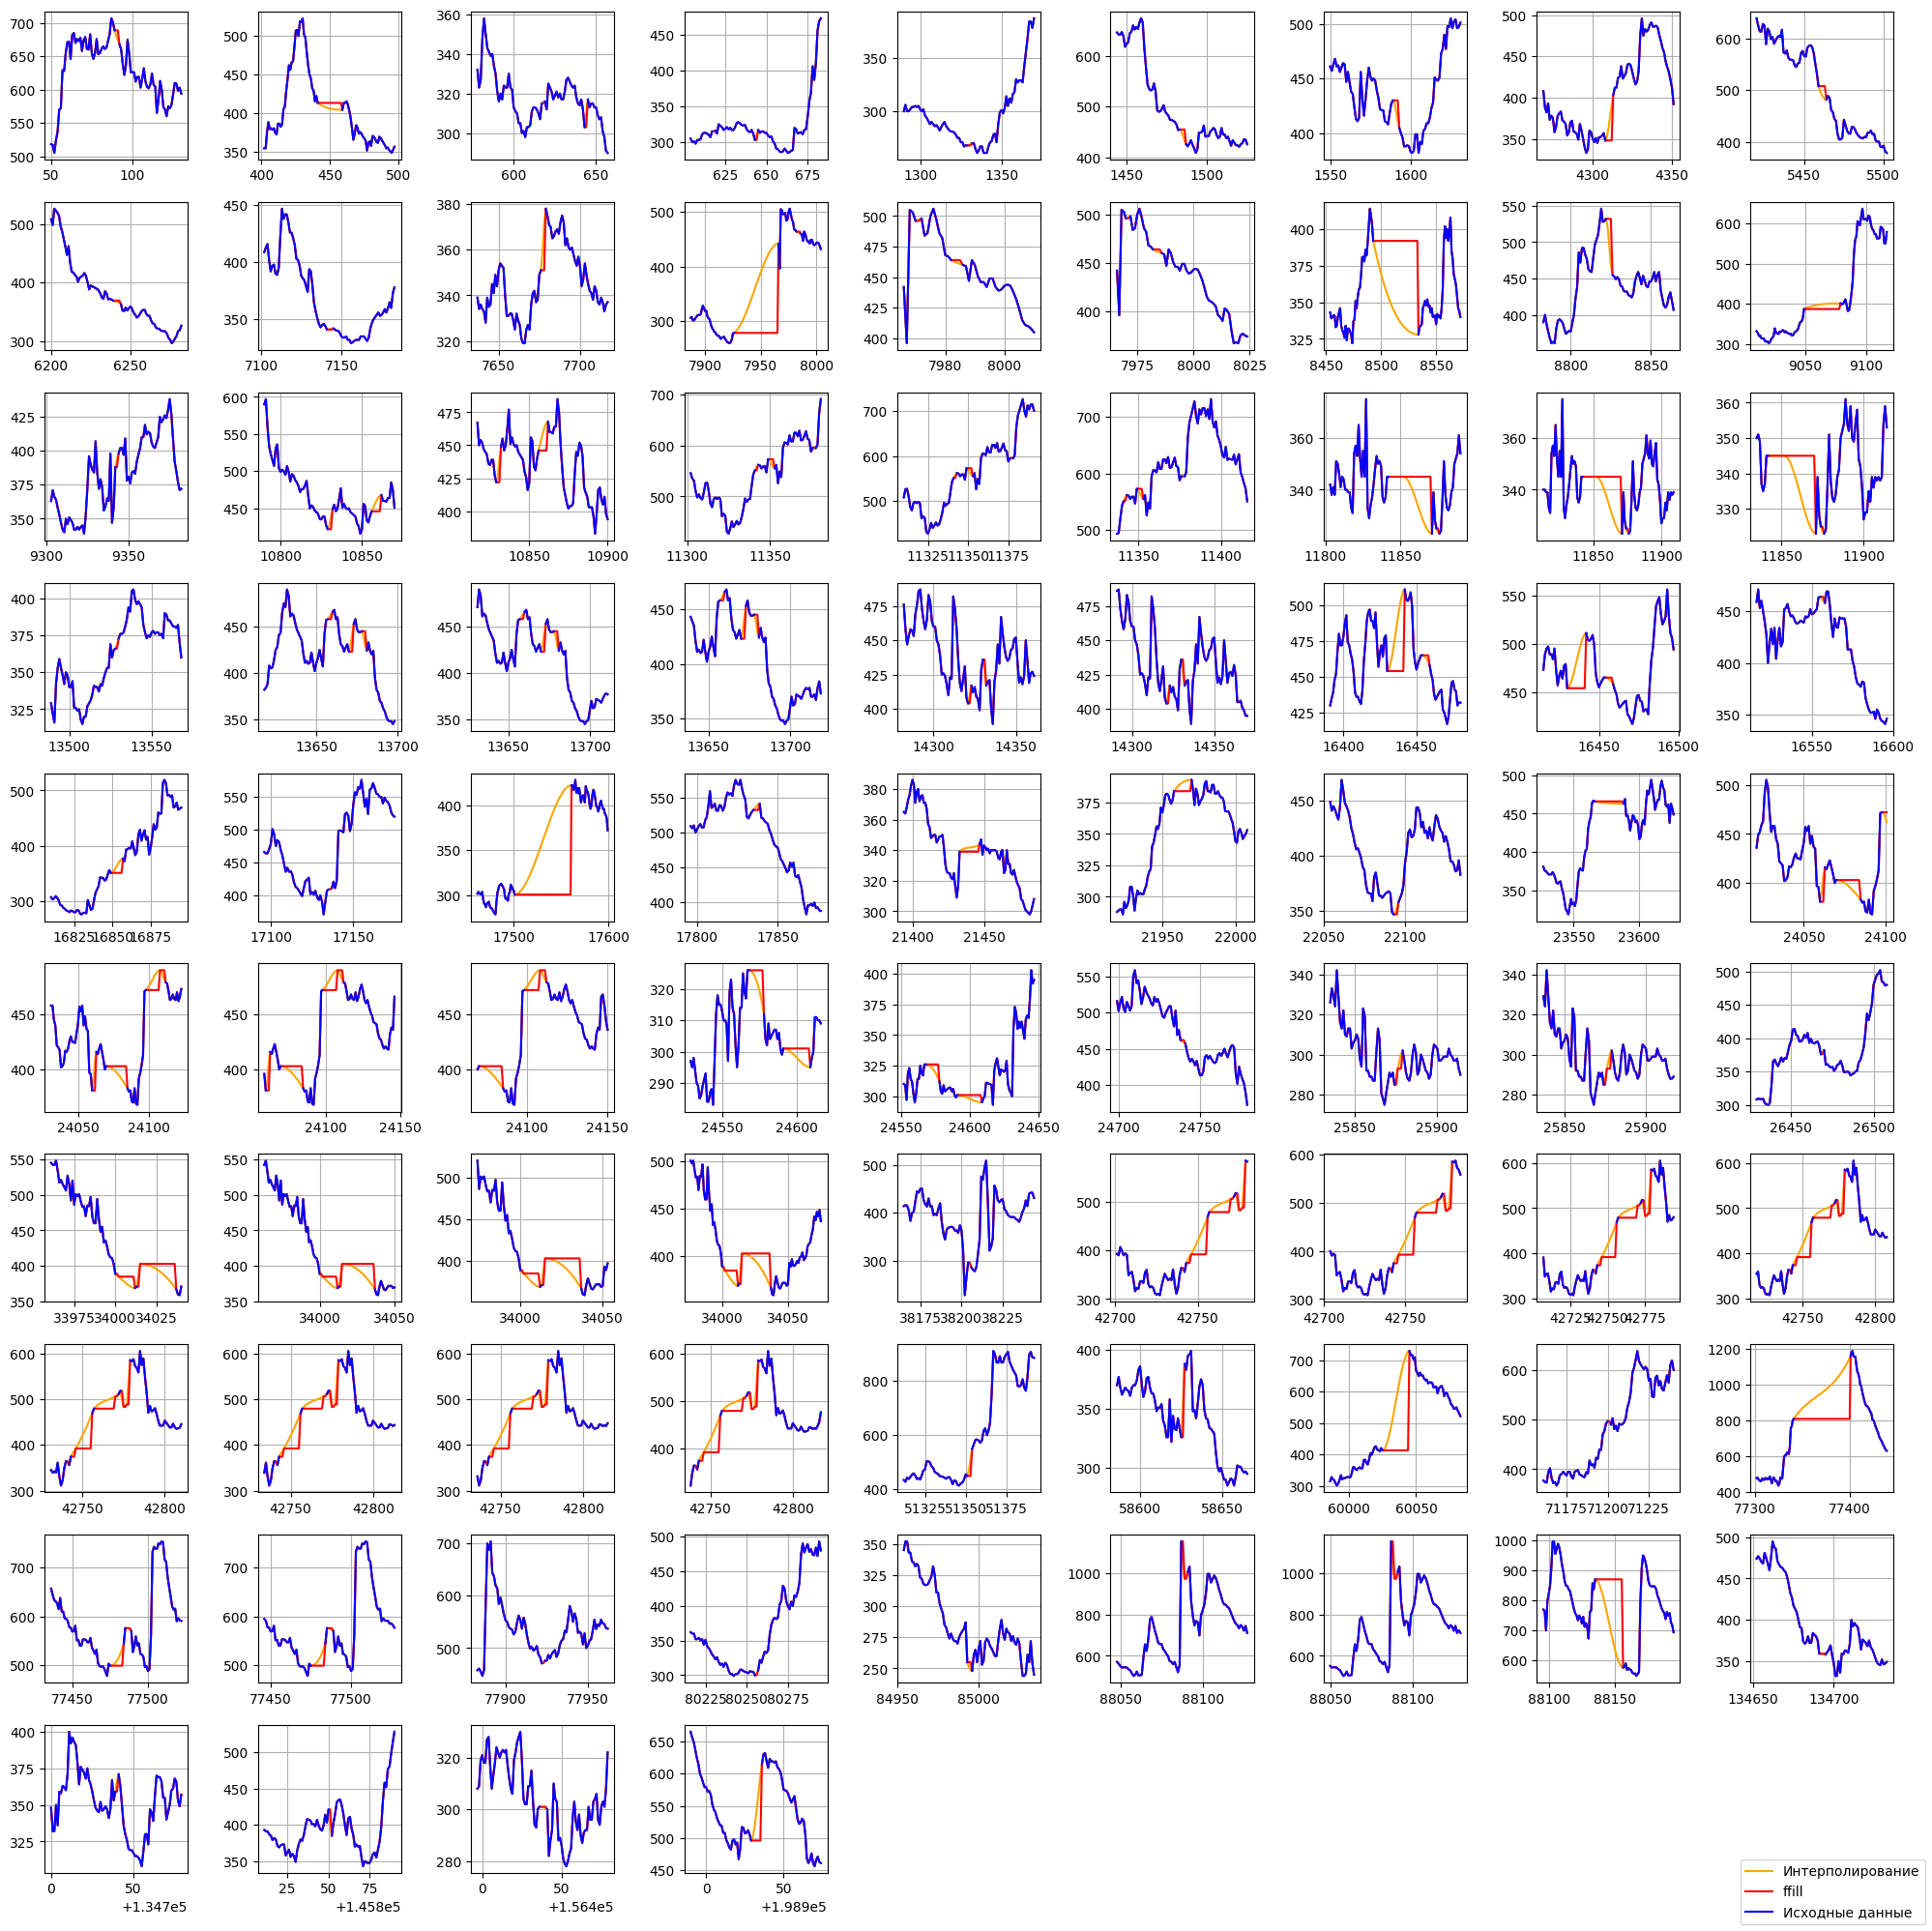

In [25]:
fig, axes = plt.subplots(10, 9, figsize=(20, 20))
axes = axes.flatten()
lines_interp = []
lines_ffills = []
lines_orig = []

for s_id, s in enumerate(v_plasma_nans):
    start, end = s["start"], s["end"]
    l1 = axes[s_id].plot(
        dataset["V_plasma"].iloc[start-history_additional:end+history_additional].interpolate(method="pchip"),
        c="orange",
        label="Интерполирование"
    )
    l2 = axes[s_id].plot(
        dataset["V_plasma"].iloc[start-history_additional:end+history_additional].ffill(),
        c="red",
        label="ffill"
    )
    l3 = axes[s_id].plot(
        dataset["V_plasma"].iloc[start-history_additional:end+history_additional],
        c="blue",
        label="Исходные данные"
    )
    axes[s_id].grid()
    if s_id == 0:
        lines_interp.append(l1[0])
        lines_ffills.append(l2[0])
        lines_orig.append(l3[0])

for i in [85, 86, 87, 88, 89]:
    fig.delaxes(axes[i])

fig.legend(
    [lines_interp[0], lines_ffills[0], lines_orig[0]],
    labels=["Интерполирование", "ffill", "Исходные данные"],
    loc='lower right',
)
plt.tight_layout()
plt.show()

In [26]:
clean_dataset = dataset.copy()
features = [i for i in clean_dataset.columns if i != "datetime"]
clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")
clean_dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [27]:
clean_dataset.isna().sum()

datetime      0
Bz_GSM        0
By_GSM        0
Bx_GSE        0
Kp            0
f10.7         0
AL            0
AU            0
T_proton      0
Np_density    0
V_plasma      0
V_Long_GSE    0
V_Lat_GSE     0
Dst           0
AE            0
dtype: int64

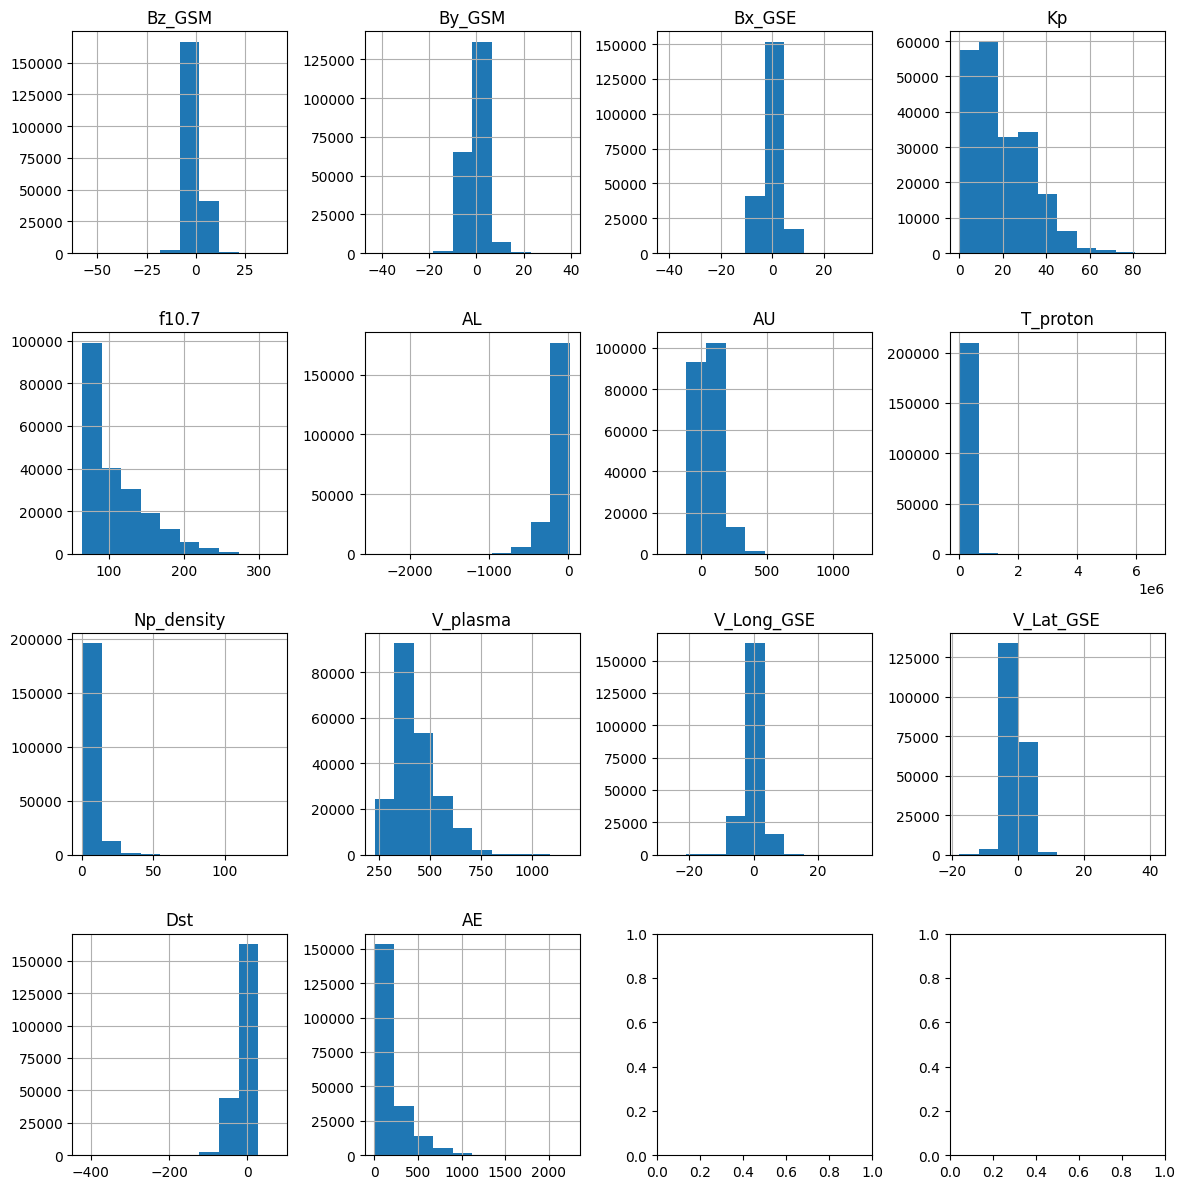

In [28]:
for_hist = clean_dataset.drop(columns=["datetime"])
n_columns = len(for_hist.columns)
grid_size = int(np.sqrt(n_columns)) + 1

fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
axes = axes.flatten()

for c_id, c in enumerate(for_hist.columns):
    axes[c_id].hist(for_hist[c].to_list())
    axes[c_id].set_title(c)
    axes[c_id].grid()

plt.tight_layout()
plt.show()

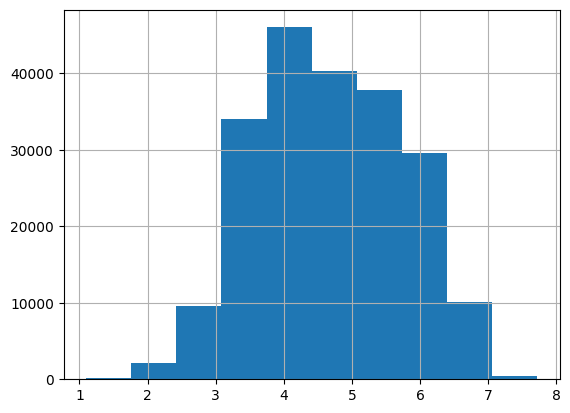

In [29]:
for_hist["AE"].apply(lambda x: np.log(x)).hist()
plt.show()

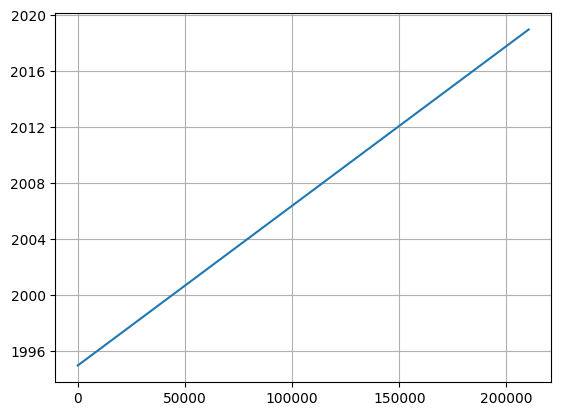

In [30]:
plt.plot(clean_dataset["datetime"])
plt.grid();

### IMF - Interplanetary Magnetic Field (межпланетное магнитное поле)

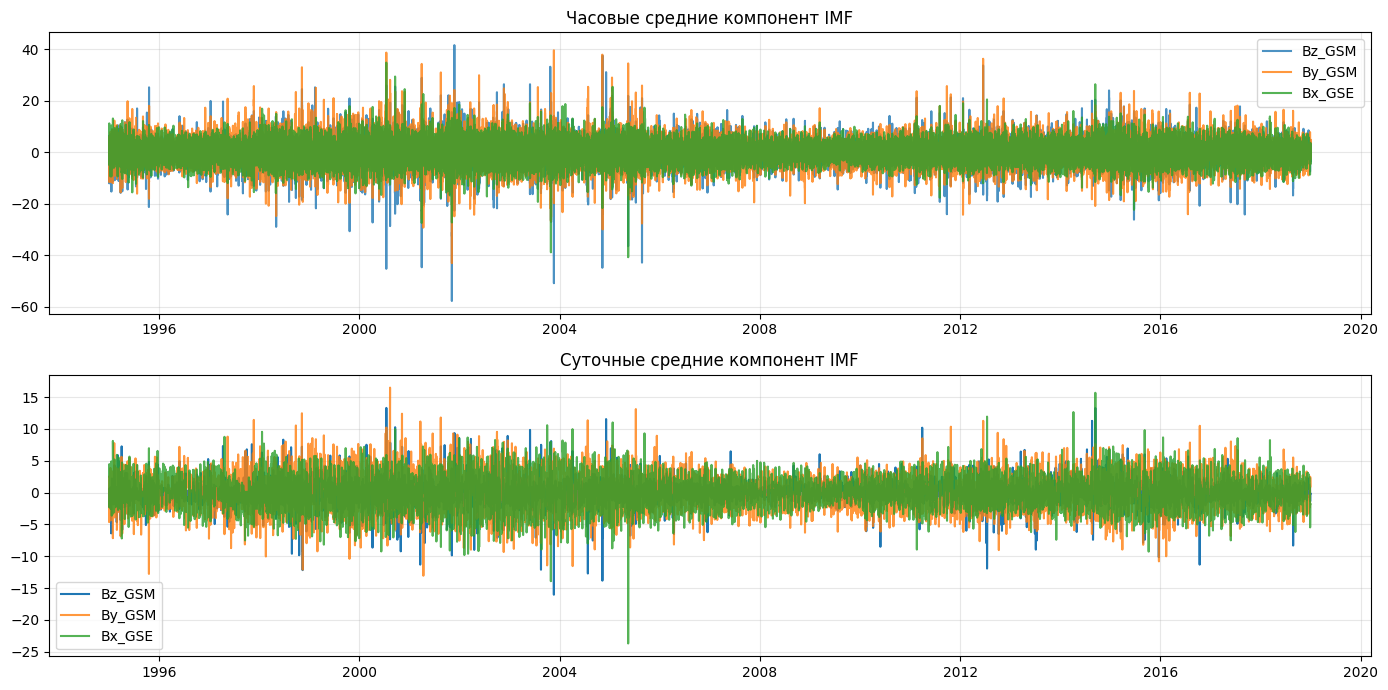

In [31]:
_, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].set_title("Часовые средние компонент IMF")
axes[0].plot(clean_dataset["datetime"], clean_dataset["Bz_GSM"], alpha=0.8, label="Bz_GSM")
axes[0].plot(clean_dataset["datetime"], clean_dataset["By_GSM"], alpha=0.8, label="By_GSM")
axes[0].plot(clean_dataset["datetime"], clean_dataset["Bx_GSE"], alpha=0.8, label="Bx_GSE")
axes[0].grid(alpha=0.3)
axes[0].legend()

daily_data = clean_dataset.set_index('datetime').resample('D').mean()
axes[1].set_title("Суточные средние компонент IMF")
axes[1].plot(daily_data.index, daily_data["Bz_GSM"], label="Bz_GSM")
axes[1].plot(daily_data.index, daily_data["By_GSM"], label="By_GSM", alpha=0.8)
axes[1].plot(daily_data.index, daily_data["Bx_GSE"], label="Bx_GSE", alpha=0.8)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [34]:
def moving_average(x, k: int):
    if not isinstance(x, pd.Series):
        x = pd.Series(x)
    return x.rolling(k).mean()

In [35]:
def make_ts_plot_with_ma(feature: pd.Series, title, label, ma_k):
    feature_ma = moving_average(feature, k=ma_k)
    plt.figure(figsize=(14, 5))
    plt.title(title)
    plt.plot(feature.index, feature, label=label)
    plt.plot(feature_ma, label="MA 120 (сезонность)")
    plt.grid(alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

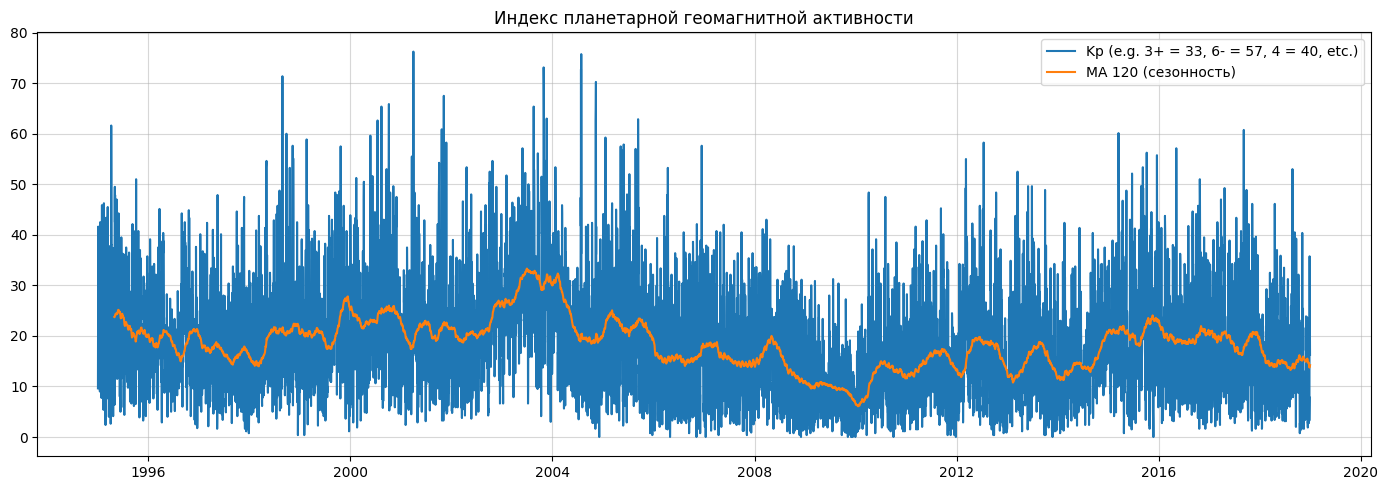

In [36]:
make_ts_plot_with_ma(
    feature=daily_data["Kp"],
    title="Индекс планетарной геомагнитной активности",
    label="Kp (e.g. 3+ = 33, 6- = 57, 4 = 40, etc.)",
    ma_k=120
)

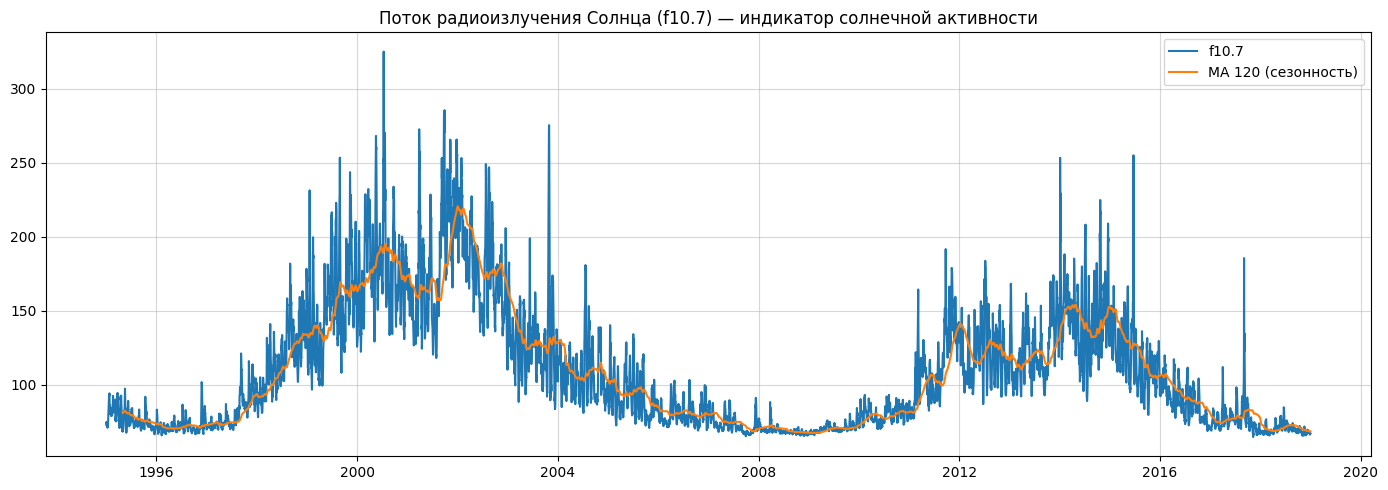

In [37]:
make_ts_plot_with_ma(
    feature=daily_data["f10.7"],
    title="Поток радиоизлучения Солнца (f10.7) — индикатор солнечной активности",
    label="f10.7",
    ma_k=120
)

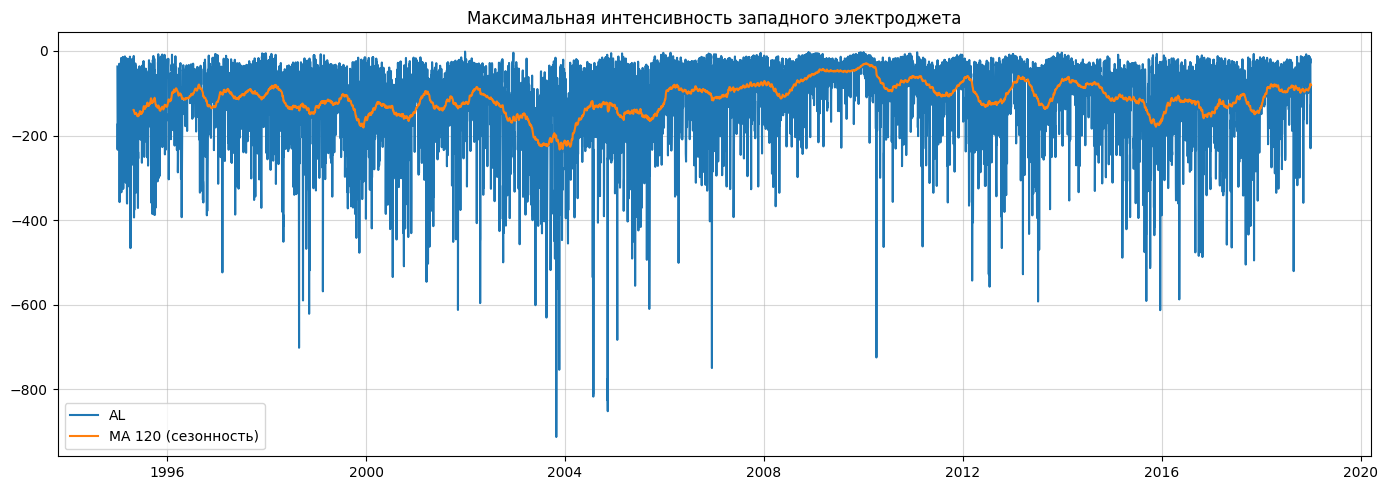

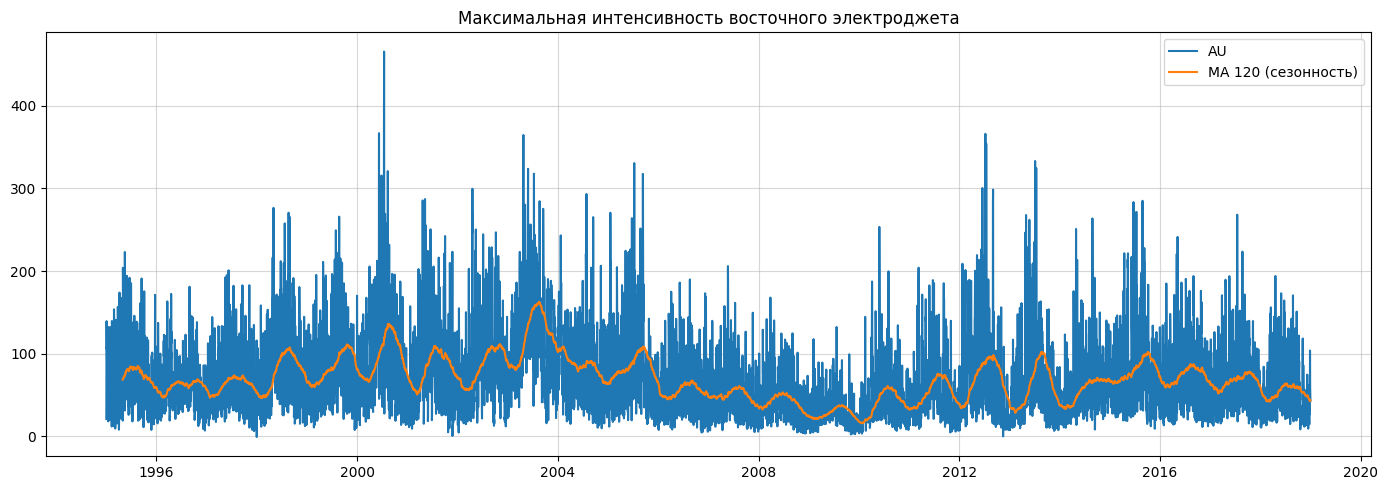

In [38]:
make_ts_plot_with_ma(
    feature=daily_data["AL"],
    title="Максимальная интенсивность западного электроджета",
    label="AL",
    ma_k=120
)
make_ts_plot_with_ma(
    feature=daily_data["AU"],
    title="Максимальная интенсивность восточного электроджета",
    label="AU",
    ma_k=120
)

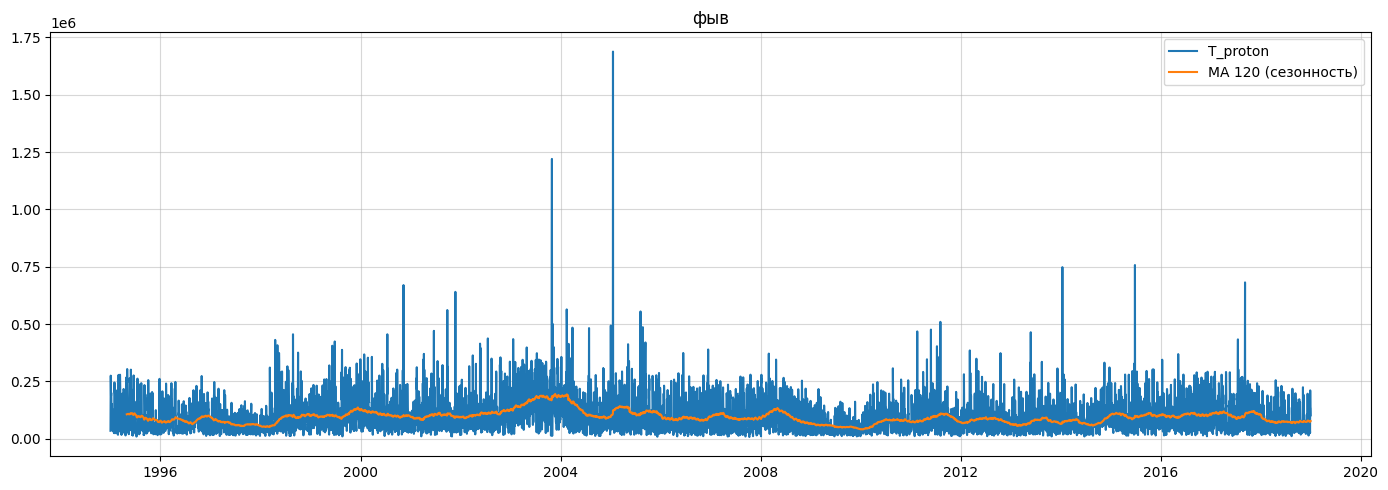

In [39]:
make_ts_plot_with_ma(
    feature=daily_data["T_proton"],
    title="фыв",
    label="T_proton",
    ma_k=120
)

### Визуализация плазменных параметров солнечного ветра

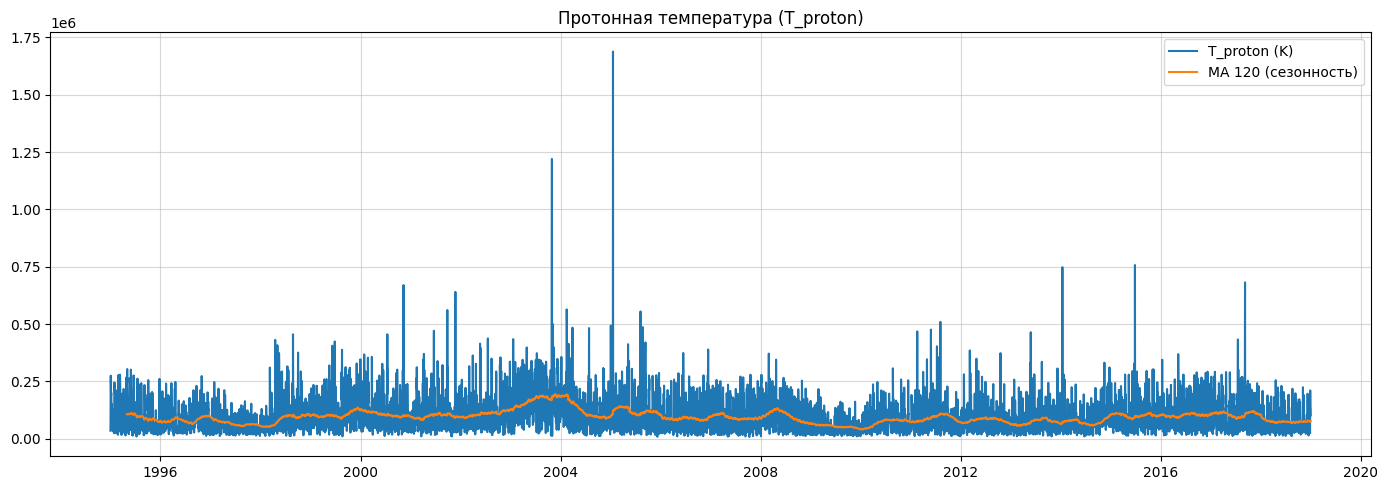

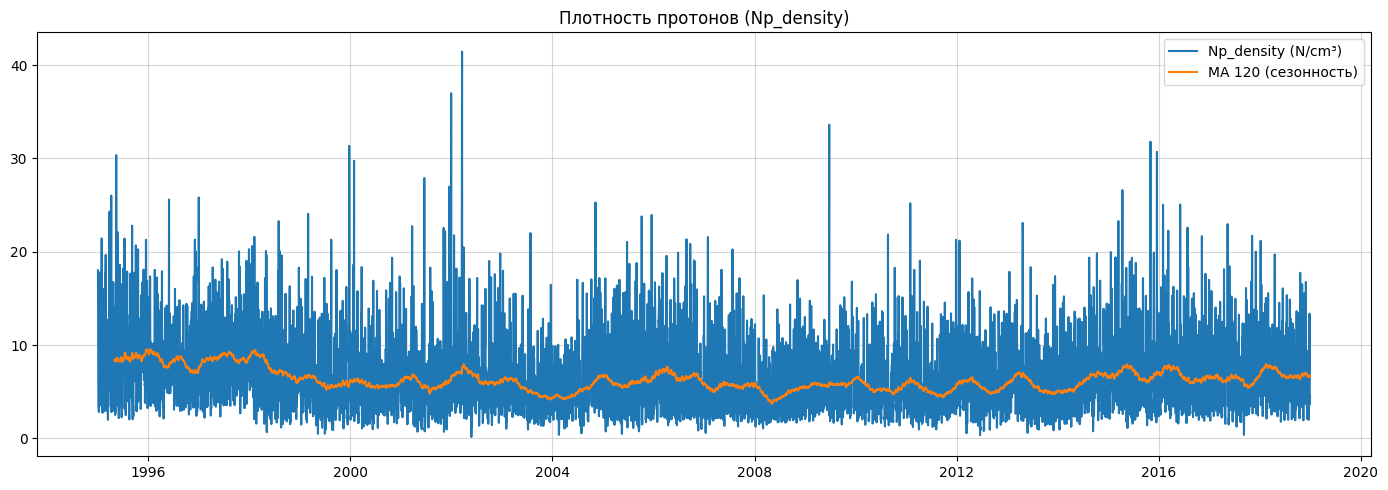

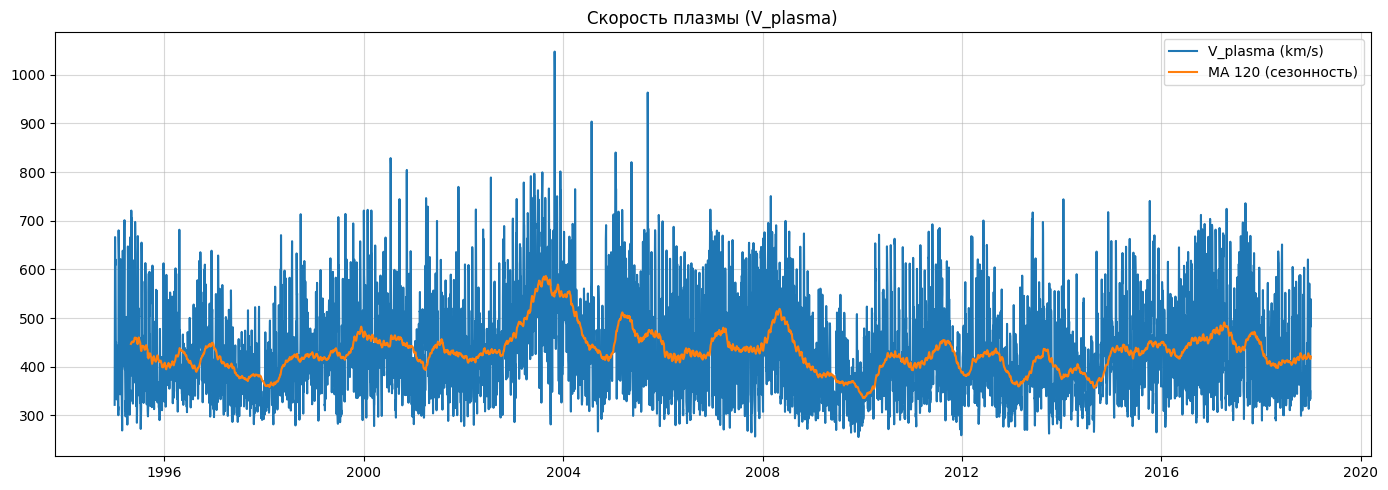

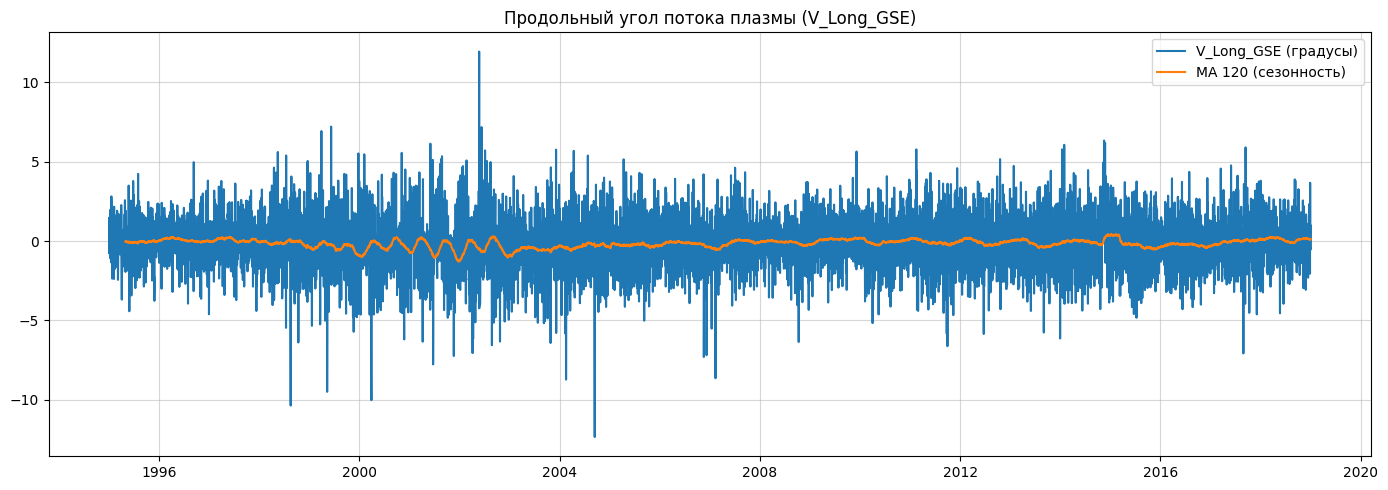

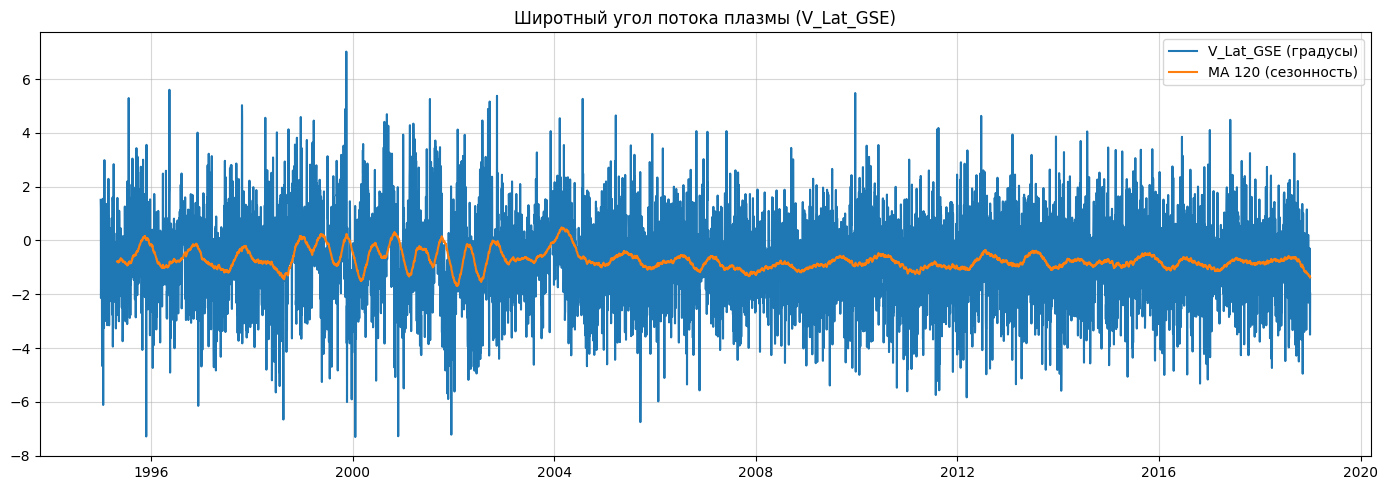

In [40]:
plasma_features = ['T_proton', 'Np_density', 'V_plasma', 'V_Long_GSE', 'V_Lat_GSE']
plasma_titles = [
    'Протонная температура (T_proton)',
    'Плотность протонов (Np_density)',
    'Скорость плазмы (V_plasma)',
    'Продольный угол потока плазмы (V_Long_GSE)',
    'Широтный угол потока плазмы (V_Lat_GSE)'
]
plasma_labels = ['T_proton (K)', 'Np_density (N/cm³)', 'V_plasma (km/s)', 'V_Long_GSE (градусы)', 'V_Lat_GSE (градусы)']

for feat, title, label in zip(plasma_features, plasma_titles, plasma_labels):
    make_ts_plot_with_ma(
        feature=daily_data[feat],
        title=title,
        label=label,
        ma_k=120,
    )

### Целевые переменные

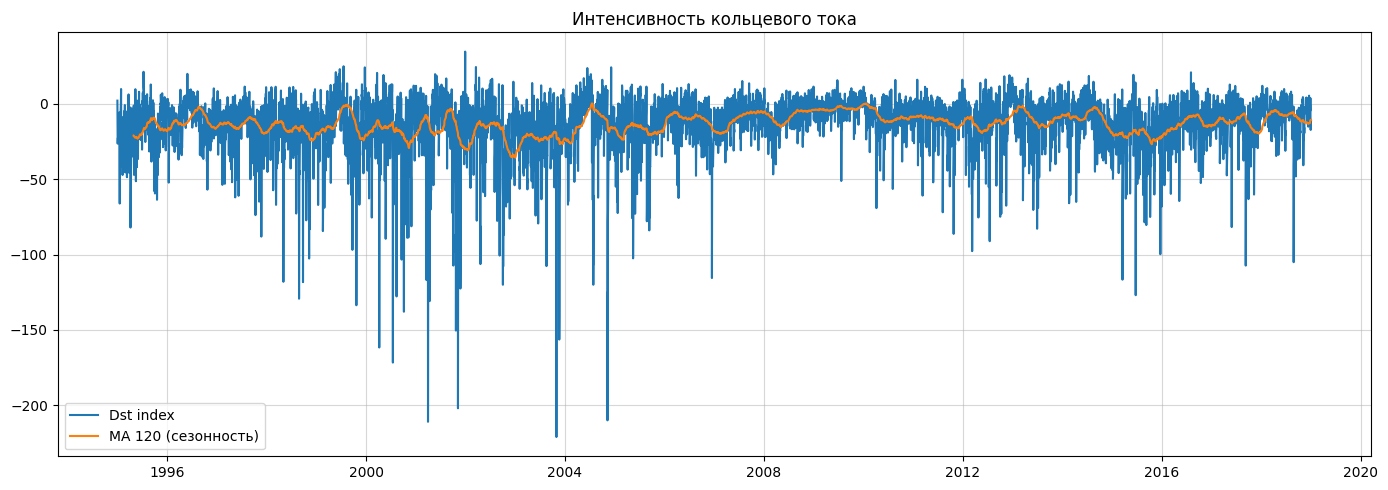

In [41]:
make_ts_plot_with_ma(
    feature=daily_data["Dst"],
    title="Интенсивность кольцевого тока",
    label="Dst index",
    ma_k=120,
)

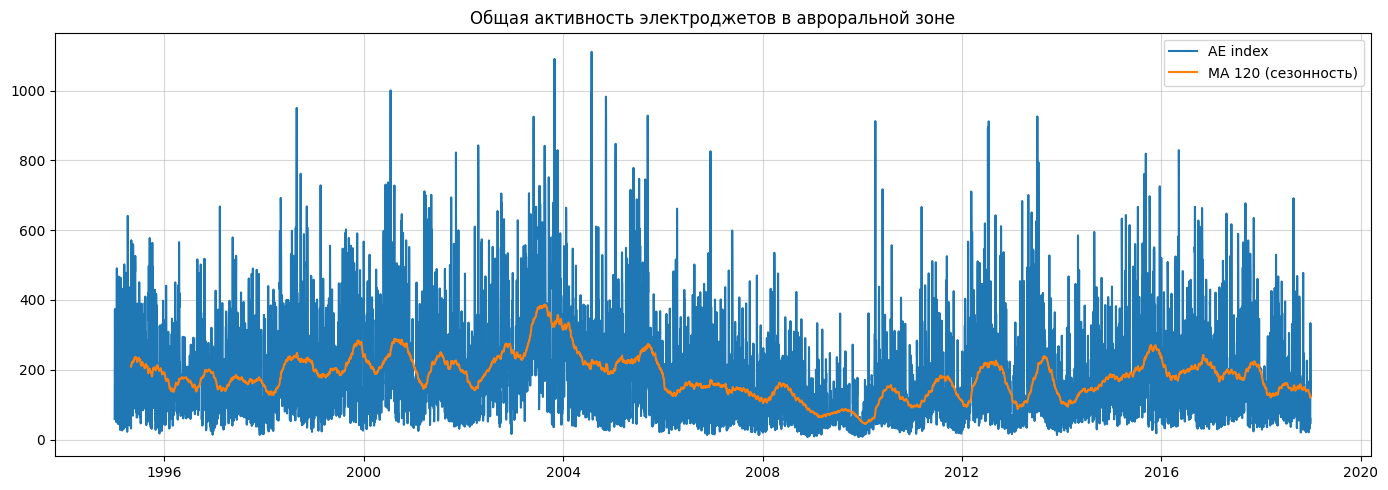

In [42]:
make_ts_plot_with_ma(
    feature=daily_data["AE"],
    title="Общая активность электроджетов в авроральной зоне",
    label="AE index",
    ma_k=120,
)

```
2019 - год низкой солнечной активности
2025 - год высокой солнечной активности
```

### Preprocessing

In [43]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import inv_boxcox
from scipy.stats import boxcox

In [44]:
clean_dataset.drop(columns=["datetime"]).describe()

,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
count,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,2.103840e+05,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000
mean,-0.049617,0.050299,-0.029005,18.441963,108.232700,-112.295911,68.111116,9.453395e+04,6.302919,430.287506,-0.151466,-0.735278,-13.242243,180.439758
std,2.998269,3.793546,3.454384,13.617466,41.372432,143.558231,68.055577,9.535070e+04,5.074199,102.397012,2.678811,2.353559,20.120794,197.759337
min,-57.800000,-43.100000,-40.800000,0.000000,64.600000,-2452.000000,-260.000000,3.299000e+03,0.100000,228.000000,-26.900000,-17.800000,-422.000000,3.000000
25%,-1.500000,-2.400000,-2.600000,7.000000,74.200000,-153.000000,22.000000,3.649000e+04,3.100000,354.000000,-1.700000,-2.100000,-21.000000,47.000000
50%,0.000000,0.000000,-0.100000,17.000000,94.100000,-52.000000,44.000000,6.788700e+04,4.900000,407.000000,-0.200000,-0.700000,-10.000000,100.000000
75%,1.400000,2.400000,2.500000,27.000000,132.900000,-21.000000,92.000000,1.233755e+05,7.800000,485.000000,1.300000,0.700000,-1.000000,245.000000
max,41.600000,39.600000,34.800000,90.000000,325.100000,22.000000,1226.000000,6.632456e+06,137.200000,1189.000000,33.800000,41.600000,77.000000,2241.000000


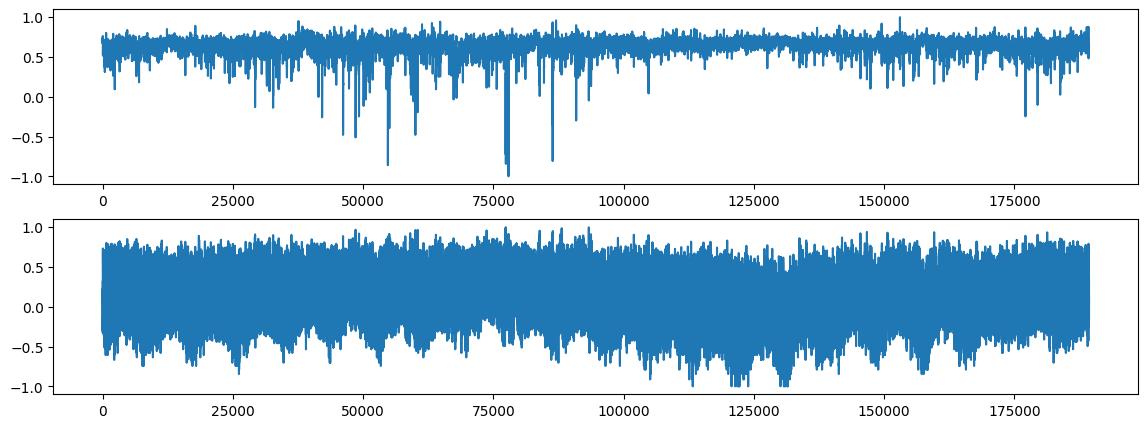

In [45]:
dataset_to_preprocess = clean_dataset.copy()

lmbda = 0
ae_log_data = boxcox(dataset_to_preprocess["AE"].to_numpy(), lmbda)

dataset_to_preprocess["AE"] = ae_log_data
# 90% train, 10% test
train_size = int(len(dataset_to_preprocess) * 0.9)

train = dataset_to_preprocess.iloc[:train_size]
test = dataset_to_preprocess.iloc[train_size:]

X_train, y_train = train.drop(columns=["datetime", "Dst", "AE"]), train[["Dst", "AE"]]
X_test, y_test = test.drop(columns=["datetime", "Dst", "AE"]), test[["Dst", "AE"]]

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = MinMaxScaler(feature_range=(-1, 1))
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

_, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].plot(y_train_scaled[:, 0])
axes[1].plot(y_train_scaled[:, 1])

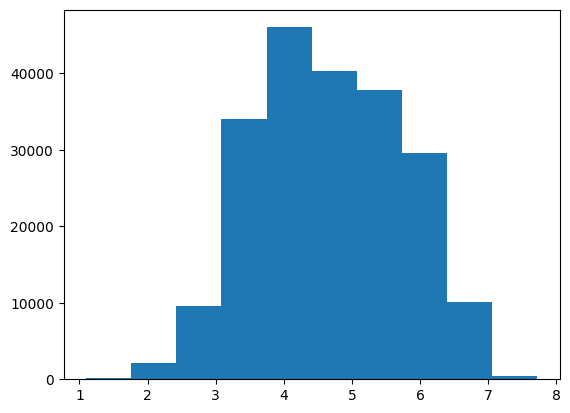

In [46]:
plt.hist(ae_log_data)
plt.show()

In [47]:
def inverse_diff(diff, first_element):
    return np.cumsum(np.concatenate([[first_element], diff]))

In [ ]:
def stationarity_test(ts):
    df_test = adfuller(ts)
    out = pd.Series(df_test[0:4], index=["Test statistic", "p-value", "Lags used", "Observations"])
    for [k, v] in df_test[4].items():
        out[f"Critical value {k}"] = f"{v}:.4f"
    print(out)

In [ ]:
def stationary_analysis(ts, lags=None, figsize=(14, 8)):
    stationarity_test(ts)
    if not isinstance(ts, pd.Series):
        ts = pd.Series(ts)
    plt.figure(figsize=figsize)
    layout = (5, 1)
    ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
    acf_ax = plt.subplot2grid(layout, (2, 0))
    pacf_ax = plt.subplot2grid(layout, (3, 0))
    qq_ax = plt.subplot2grid(layout, (4, 0))

    ts.plot(ax=ts_ax, color="blue", label="Or")
    ts_ax.set_title("Original")
    sm_ts_api.graphics.plot_acf(ts, lags=lags, ax=acf_ax, alpha=0.5)
    sm_ts_api.graphics.plot_pacf(ts, lags=lags, ax=pacf_ax, alpha=0.5)
    sm_api.qqplot(ts, line="s", ax=qq_ax)

    plt.tight_layout()
    plt.show()

In [48]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  # [y_window_size, 2]

        return x_window, y_window

In [50]:
X_window_size = 24*7  # 2 недели
y_window_size = 6
batch_size = 32
stride = y_window_size

train_dataset = GeomagneticDataset(
    X=X_train_scaled,
    y=y_train_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
test_dataset = GeomagneticDataset(
    X=X_test_scaled,
    y=y_test_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
?nn.LSTM

In [51]:
class GeomagnetiсModel(nn.Module):
    def __init__(
        self,
        lstm_input_size: int,
        lstm_hidden_size: int,
        lstm_num_layers: int,
        lstm_dropout: float,
        attention_num_heads: int,  
        forecasts_len: int,
        *args,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.rnn_feature_extractor = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0,
            batch_first=True,
        )
        self.attention = nn.MultiheadAttention(
            embed_dim=lstm_hidden_size,      
            num_heads=attention_num_heads,   
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.attention_norm = nn.LayerNorm(lstm_hidden_size)
        self.dropout = nn.Dropout(lstm_dropout)
        heads_hidden_size = lstm_hidden_size * 2
        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )
        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        lstm_out, (_, _) = self.rnn_feature_extractor(x)
        attn_out, attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        lstm_out = self.attention_norm(lstm_out + attn_out)
        features = lstm_out[:, -1, :]  
        features = self.dropout(features)
        dst = self.dst_head(features) 
        ae = self.ae_head(features)   
        
        return dst, ae, attn_weights

Кол-во весов: 5293068


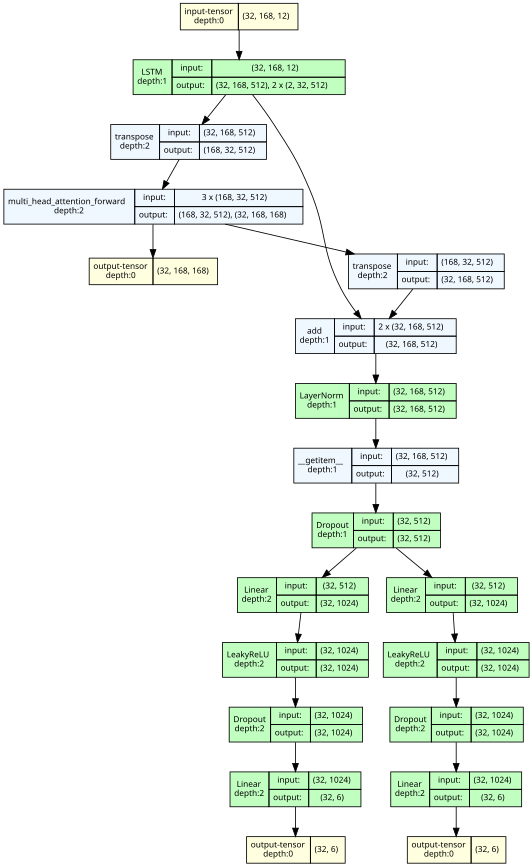

In [52]:
initial_lr = 1e-4
lr_scheduler_step_size = 15
lr_scheduler_gamma = 0.7
EPOCHS = 9999999


baseline_model = GeomagnetiсModel(
    lstm_input_size=12,
    lstm_hidden_size=512,
    lstm_num_layers=2,
    lstm_dropout=0.2,
    attention_num_heads=8,
    forecasts_len=y_window_size,
)
print(f"Кол-во весов: {sum([i.numel() for i in baseline_model.parameters()])}")
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(baseline_model.parameters(), lr=initial_lr, weight_decay=0.01)
lr_scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=lr_scheduler_step_size, gamma=lr_scheduler_gamma)

graph = draw_graph(baseline_model, input_size=[batch_size, X_window_size, 12])
graph.visual_graph

In [54]:
from sklearn.metrics import (
    mean_absolute_percentage_error, 
    root_mean_squared_error, 
    mean_absolute_error,
)

In [ ]:
patience_counter = 0
patience_delta = 1e-3
patience = 50

best_dst_rmse = 99999999999

history_train = {
    "dst_loss": [],
    "ae_loss": [],
    "summary_loss": [],
    "ae": {"RMSE": [], "MAPE": [], "MAE": []},
    "dst": {"RMSE": [], "MAPE": [], "MAE": []}
}
history_test = {
    "ae": {"RMSE": [], "MAPE": [], "MAE": []},
    "dst": {"RMSE": [], "MAPE": [], "MAE": []}
}

baseline_model.to(device)

for e in range(EPOCHS):
    # !!! TRAIN !!!
    baseline_model.train()
    train_progress = tqdm(train_loader)
    running_history = {"dst_loss": [], "ae_loss": [], "summary_loss": [], "ae": {"RMSE": [], "MAPE": [], "MAE": [],}, "dst": {"RMSE": [], "MAPE": [], "MAE": [],}}
    for x, y in train_progress:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        dst_y, ae_y = y[:, :, 0], y[:, :, 1]
        dst_y_pred, ae_y_pred = baseline_model(x)

        dst_loss = loss_fn(dst_y_pred, dst_y)
        ae_loss = loss_fn(ae_y_pred, ae_y)

        loss = dst_loss + ae_loss
        loss.backward()
        # Metrics based on the original data scale
        pred_data = np.stack([dst_y_pred.detach().cpu().numpy().flatten(), ae_y_pred.detach().cpu().numpy().flatten()], axis=1)
        label_data = np.stack([dst_y.detach().cpu().numpy().flatten(), ae_y.detach().cpu().numpy().flatten()], axis=1)
        pred_data = y_scaler.inverse_transform(pred_data)
        pred_data[:, 1] = inv_boxcox(pred_data[:, 1], lmbda)  # ae from log
        label_data = y_scaler.inverse_transform(label_data)
        label_data[:, 1] = inv_boxcox(label_data[:, 1], lmbda)  # ae from log
        dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
        ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
        dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
        ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
        dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
        ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])
        # Collecting 
        running_history["dst"]["RMSE"].append(dst_rmse)
        running_history["ae"]["RMSE"].append(ae_rmse)
        running_history["dst"]["MAPE"].append(dst_mape)
        running_history["ae"]["MAPE"].append(ae_mape)
        running_history["dst"]["MAE"].append(dst_mae)
        running_history["ae"]["MAE"].append(ae_mae)
        running_history["dst_loss"].append(dst_loss.item())
        running_history["ae_loss"].append(ae_loss.item())
        running_history["summary_loss"].append(loss.item())

        optimizer.step()

        train_progress.set_description(
            f"Epoch [{e+1:>3}/{EPOCHS}] Stage [TRAIN] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} dst-MAPE {dst_mape:.3f} ae-MAPE {ae_mape:.3f} dst-MAE {dst_mae:.3f} ae-MAE {ae_mae:.3f} Loss {loss.item():.3f}"
        )
    history_train["dst"]["RMSE"].append(np.mean(running_history["dst"]["RMSE"]))
    history_train["ae"]["RMSE"].append(np.mean(running_history["ae"]["RMSE"]))
    history_train["dst"]["MAPE"].append(np.mean(running_history["dst"]["MAPE"]))
    history_train["ae"]["MAPE"].append(np.mean(running_history["ae"]["MAPE"]))
    history_train["dst"]["MAE"].append(np.mean(running_history["dst"]["MAE"]))
    history_train["ae"]["MAE"].append(np.mean(running_history["ae"]["MAE"]))
    history_train["dst_loss"].append(np.mean(running_history["dst_loss"]))
    history_train["ae_loss"].append(np.mean(running_history["ae_loss"]))
    history_train["summary_loss"].append(np.mean(running_history["summary_loss"]))
    lr_scheduler.step()
    # !!! TEST !!!
    with torch.no_grad():
        baseline_model.eval()
        test_progress = tqdm(test_loader)
        running_history = {"ae": {"RMSE": [], "MAPE": [], "MAE": [],}, "dst": {"RMSE": [], "MAPE": [], "MAE": [],}}
        for x, y in test_progress:
            x, y = x.to(device), y.to(device)
            dst_y, ae_y = y[:, :, 0], y[:, :, 1]
            dst_y_pred, ae_y_pred = baseline_model(x)
            pred_data = np.stack([dst_y_pred.detach().cpu().numpy().flatten(), ae_y_pred.detach().cpu().numpy().flatten()], axis=1)
            label_data = np.stack([dst_y.detach().cpu().numpy().flatten(), ae_y.detach().cpu().numpy().flatten()], axis=1)
            pred_data = y_scaler.inverse_transform(pred_data)
            pred_data[:, 1] = inv_boxcox(pred_data[:, 1], lmbda)  # ae from log
            label_data = y_scaler.inverse_transform(label_data)
            label_data[:, 1] = inv_boxcox(label_data[:, 1], lmbda)  # ae from log
            dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
            ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
            dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
            ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
            dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
            ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])
            running_history["dst"]["RMSE"].append(dst_rmse)
            running_history["ae"]["RMSE"].append(ae_rmse)
            running_history["dst"]["MAPE"].append(dst_mape)
            running_history["ae"]["MAPE"].append(ae_mape)
            running_history["dst"]["MAE"].append(dst_mae)
            running_history["ae"]["MAE"].append(ae_mae)
            test_progress.set_description(
                f"Epoch [{e+1:>3}/{EPOCHS}] Stage [ TEST] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} dst-MAPE {dst_mape:.3f} ae-MAE {ae_mape:.3f} dst-MAE {dst_mae:.3f} ae-MAE {ae_mae:.3f}"
            )
        history_test["dst"]["RMSE"].append(np.mean(running_history["dst"]["RMSE"]))
        history_test["ae"]["RMSE"].append(np.mean(running_history["ae"]["RMSE"]))
        history_test["dst"]["MAPE"].append(np.mean(running_history["dst"]["MAPE"]))
        history_test["ae"]["MAPE"].append(np.mean(running_history["ae"]["MAPE"]))
        history_test["dst"]["MAE"].append(np.mean(running_history["dst"]["MAE"]))
        history_test["ae"]["MAE"].append(np.mean(running_history["ae"]["MAE"]))
    # Сhecking the patience condition
    last_dst_rmse =  history_test["dst"]["RMSE"][-1]
    if last_dst_rmse < best_dst_rmse - patience_delta:
        best_dst_rmse = last_dst_rmse
        torch.save(baseline_model.state_dict(), "./best.pt")
        patience_counter = 0
        print(f"Save best model! epoch={e}")
    else:
        patience_counter += 1
    if patience_counter >= patience:
        torch.save(baseline_model.state_dict(), "./last.pt")
        print(f"Early stopping at epoch {e}. Best epoch={e-patience}")
        break

Epoch [  1/100] Stage [TRAIN] Loss 0.046 dst-MAPE 14.155 ae-MAPE 180.691: 100%|██████████| 493/493 [00:19<00:00, 25.44it/s]
Epoch [  2/100] Stage [TRAIN] Loss 0.046 dst-MAPE 14.544 ae-MAPE 189.268: 100%|██████████| 493/493 [00:19<00:00, 25.40it/s]
Epoch [  3/100] Stage [TRAIN] Loss 0.043 dst-MAPE 14.462 ae-MAPE 179.174: 100%|██████████| 493/493 [00:18<00:00, 26.10it/s]
Epoch [  4/100] Stage [TRAIN] Loss 0.039 dst-MAPE 11.229 ae-MAPE 164.448: 100%|██████████| 493/493 [00:18<00:00, 26.17it/s]
Epoch [  5/100] Stage [TRAIN] Loss 0.043 dst-MAPE 14.082 ae-MAPE 174.324: 100%|██████████| 493/493 [00:19<00:00, 25.94it/s]
Epoch [  6/100] Stage [TRAIN] Loss 0.042 dst-MAPE 16.128 ae-MAPE 166.950: 100%|██████████| 493/493 [00:19<00:00, 24.84it/s]
Epoch [  7/100] Stage [TRAIN] Loss 0.042 dst-MAPE 14.881 ae-MAPE 170.870: 100%|██████████| 493/493 [00:19<00:00, 24.78it/s]
Epoch [  8/100] Stage [TRAIN] Loss 0.040 dst-MAPE 14.806 ae-MAPE 171.539: 100%|██████████| 493/493 [00:19<00:00, 24.93it/s]
Epoch [ 

KeyboardInterrupt: 

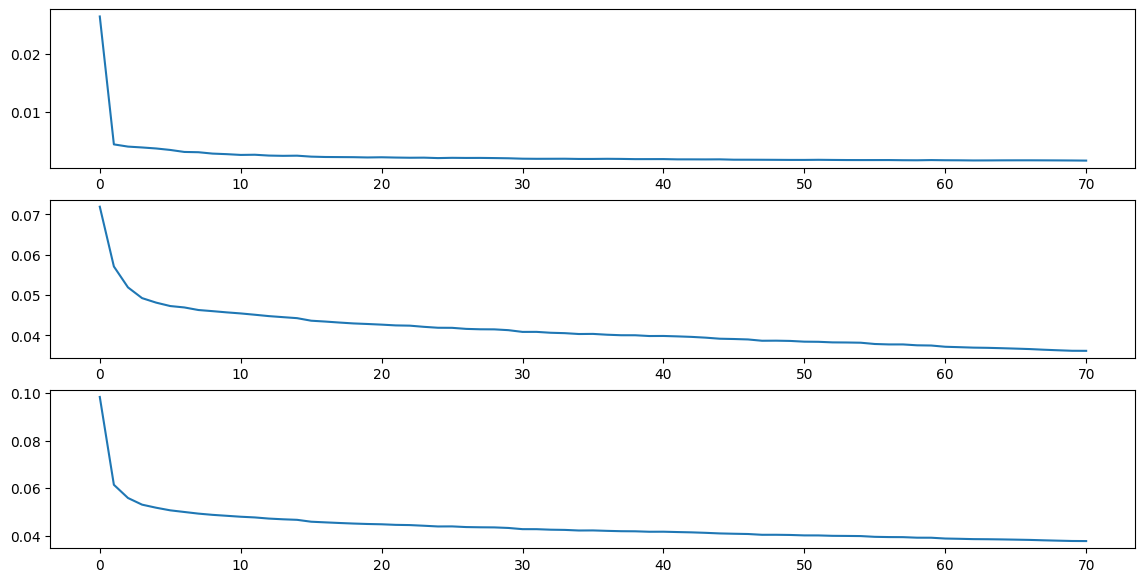

In [ ]:
_, axes = plt.subplots(3, 1, figsize=(14, 7))
axes[0].plot(history_train["dst_loss"])
axes[1].plot(history_train["ae_loss"])
axes[2].plot(history_train["summary_loss"])

In [36]:
dst_labels = []
ae_labels = []
dst_preds = []
ae_preds = []

with torch.no_grad():
  baseline_model.eval()
  for x, y in test_loader:
    dst_l, ae_l = y[:, :, 0], y[:, :, 1]
    for i in dst_l.flatten():
      dst_labels.append(i)
    for i in ae_l.flatten():
      ae_labels.append(i)
    x, y = x.to(device), y.to(device)

    dst_pred, ae_pred = baseline_model(x)
    for i in dst_pred.detach().cpu().flatten():
      dst_preds.append(i.item())
    for i in ae_pred.detach().cpu().flatten():
      ae_preds.append(i.item())

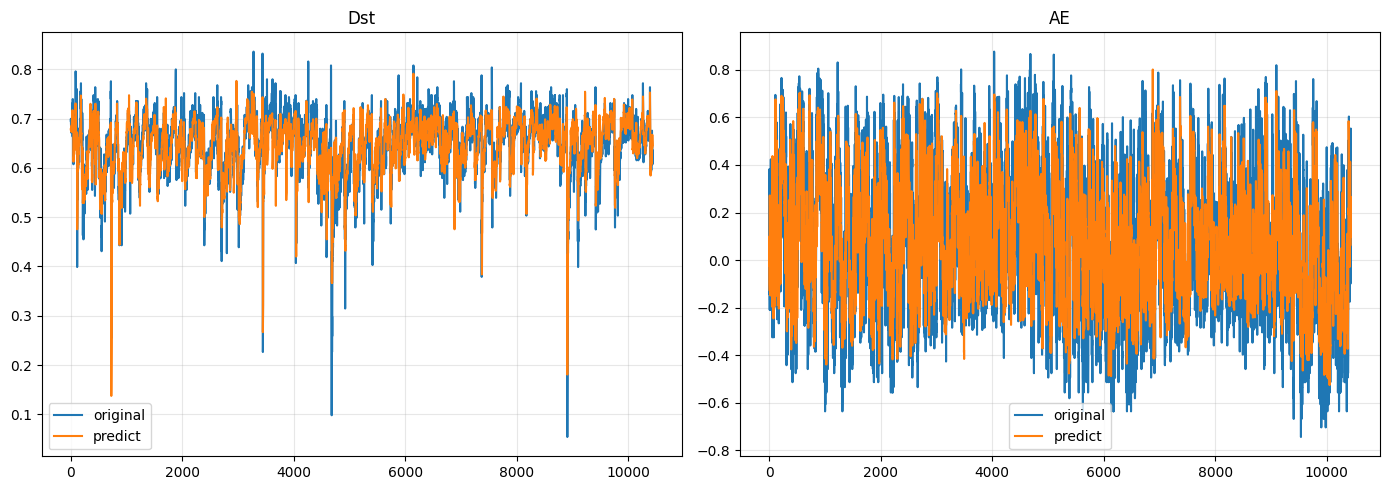

In [37]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Dst")
axes[0].plot(dst_labels, label="original")
axes[0].plot(dst_preds, label="predict")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("AE")
axes[1].plot(ae_labels, label="original")
axes[1].plot(ae_preds, label="predict")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()